In [1]:
#import statements
import os
import copy
from pathlib import Path
from glob import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nibabel as nib
import nilearn
import nilearn.image
import nilearn.plotting
import ants
import nilearn.image as nli
import nilearn.plotting as nlp
import pydicom
import pyarrow.parquet as pq

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
from torchinfo import summary

from sklearn.decomposition import PCA
from sklearn.metrics import (
    balanced_accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc,
)
from sklearn.model_selection import (
    StratifiedGroupKFold, cross_validate, train_test_split,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import label_binarize, MinMaxScaler, StandardScaler
from sklearn.svm import SVC

In [2]:
DATA     = Path("model_data/adni")
T1_LONG  = DATA / "t1_long_data"
DTI_LONG = DATA / "dti_long_data"

meta = pd.read_csv(DATA / "paired_df_long_v2.csv")
MODALITIES = ["t1_gm", "t1_wm", "t1_csf", "dti_gm", "dti_wm", "dti_csf"]

print(f"Cohort: {len(meta)} paired subjects")
print("group:  ", meta["group"].value_counts().to_dict())
print("amyloid:", meta["amyloid_label"].value_counts(dropna=False).to_dict())

Cohort: 786 paired subjects
group:   {'CN': 411, 'MCI': 282, 'Dementia': 77}
amyloid: {0.0: 387, 1.0: 336, nan: 63}


In [3]:
key_col = {
    "t1_gm":  "t1_image_subject_id",
    "t1_wm":  "t1_image_subject_id",
    "t1_csf": "t1_image_subject_id",
    "dti_gm": "dti_image_subject_id",
    "dti_wm": "dti_image_subject_id",
    "dti_csf":"dti_image_subject_id",
}
parquet_paths = {
    "t1_gm":  T1_LONG  / "t1_long_masked_gm.parquet",
    "t1_wm":  T1_LONG  / "t1_long_masked_wm.parquet",
    "t1_csf": T1_LONG  / "t1_long_masked_csf.parquet",
    "dti_gm": DTI_LONG / "dti_long_masked_gm_md.parquet",
    "dti_wm": DTI_LONG / "dti_long_masked_wm_md.parquet",
    "dti_csf":DTI_LONG / "dti_long_masked_csf_md.parquet",
}

# Parquets can exceed pyarrow's default thrift limit (~1 GB metadata) — raise it.
def _read_parquet(path):
    return pq.read_pandas(str(path),
                          thrift_string_size_limit=2_000_000_000,
                          thrift_container_size_limit=2_000_000_000).to_pandas()

X_raw = {}
for k, p in parquet_paths.items():
    df = _read_parquet(p)
    X_raw[k] = df.loc[meta[key_col[k]]].values.astype(np.float32)
    print(f"  {k}: {X_raw[k].shape}")

  t1_gm: (786, 831863)
  t1_wm: (786, 785285)
  t1_csf: (786, 337620)
  dti_gm: (786, 831863)
  dti_wm: (786, 785285)
  dti_csf: (786, 337620)


In [4]:
# ── MNI ROI-based PCA model ──────────────────────────────────────────────────
# Harvard-Oxford cortical+subcortical atlas defines ROIs.
# For each fold: StandardScaler (fit on CN train) + PCA per ROI capturing ≥90%
# variance (randomized SVD, capped at 50 components), then SVC on concatenated
# PC scores. Final classification uses score fusion across all 6 modalities.

VAR_THRESHOLD    = 0.90   # fraction of variance each per-ROI PCA must capture
N_MAX_PC_PER_ROI = 50     # cap for randomized SVD speed

# ── 1. Load atlas & tissue masks resampled to subject T1 reference space ─────

_ref_path = next(
    Path("model_data/adni/t1_long_data/t1_long_modulated_vbm/t1_long_pve_smoothed")
    .glob("*/*_pve_1_mod_s2p5.nii.gz")
)
_ref_img = nib.load(str(_ref_path))

def _resample_nearest(src_path):
    return nli.resample_to_img(str(src_path), _ref_img,
                               interpolation="nearest",
                               force_resample=True, copy_header=True)

_gm_mask  = np.asarray(_resample_nearest("model_data/mni_gm_mask_fast.nii").dataobj) > 0.5
_wm_mask  = np.asarray(_resample_nearest("model_data/mni_wm_mask_fast.nii").dataobj) > 0.5
_csf_mask = np.asarray(_resample_nearest("model_data/mni_csf_mask_fast.nii").dataobj) > 0.5

_atlas_vol  = np.round(
    np.asarray(_resample_nearest("model_data/HO_cort_sub_combined.nii").dataobj)
).astype(int)
_atlas_flat = _atlas_vol.ravel()

_roi_labels = np.unique(_atlas_flat)
_roi_labels = _roi_labels[_roi_labels > 0]

_tissue_mask = {
    "t1_gm":  _gm_mask,   "dti_gm":  _gm_mask,
    "t1_wm":  _wm_mask,   "dti_wm":  _wm_mask,
    "t1_csf": _csf_mask,  "dti_csf": _csf_mask,
}

# roi_col_idx[mod][roi_label] = column indices into X_raw[mod] that fall in ROI
roi_col_idx = {}
for _mod in MODALITIES:
    _mask_idx      = np.where(_tissue_mask[_mod].ravel())[0]
    _atlas_in_mask = _atlas_flat[_mask_idx]
    roi_col_idx[_mod] = {
        int(roi): np.where(_atlas_in_mask == roi)[0]
        for roi in _roi_labels
        if (_atlas_in_mask == roi).any()
    }

print("ROIs covered per modality (Harvard-Oxford atlas):")
for _mod in MODALITIES:
    _n   = len(roi_col_idx[_mod])
    _tot = sum(len(v) for v in roi_col_idx[_mod].values())
    print(f"  {_mod}: {_n:>3} ROIs  {_tot:>8,} voxels covered")

# ── 2. Per-ROI PCA helpers ────────────────────────────────────────────────────

def fit_roi_pca(X_tr, cn_idx, roi_cols,
                var_thr=VAR_THRESHOLD, n_max=N_MAX_PC_PER_ROI):
    pipes = []
    for cols in roi_cols.values():
        Xr  = X_tr[cn_idx][:, cols].astype(np.float32)
        sc  = StandardScaler().fit(Xr)
        Xs  = sc.transform(Xr)
        k   = min(Xs.shape[0] - 1, Xs.shape[1], n_max)
        if k < 1:
            pipes.append((sc, None, cols))
            continue
        pca = PCA(n_components=k, svd_solver="randomized", random_state=0).fit(Xs)
        cum    = np.cumsum(pca.explained_variance_ratio_)
        n_keep = min(int(np.searchsorted(cum, var_thr)) + 1, k)
        for _attr in ("components_", "explained_variance_",
                      "explained_variance_ratio_", "singular_values_"):
            setattr(pca, _attr, getattr(pca, _attr)[:n_keep])
        pca.n_components_ = n_keep
        pipes.append((sc, pca, cols))
    return pipes


def transform_roi_pca(X, pipes):
    parts = []
    for sc, pca, cols in pipes:
        Xs = sc.transform(X[:, cols].astype(np.float32))
        parts.append(pca.transform(Xs) if pca is not None else Xs)
    return np.hstack(parts)


# ── 3. 5-fold CV: per-ROI PCA + SVC with score fusion ────────────────────────

_tasks_roi = {
    "CN vs Dementia":     meta["group"].isin(["CN", "Dementia"]),
    "CN vs MCI":          meta["group"].isin(["CN", "MCI"]),
    "CN vs MCI+Dementia": meta["group"].notna(),
}

roi_cv_records = []

for _task_name, _task_mask in _tasks_roi.items():
    _sub  = meta[_task_mask].reset_index(drop=True)
    _y    = _sub["group"].map({"CN": 0, "MCI": 1, "Dementia": 1}).values.astype(np.int64)
    _grp  = _sub["subject_id"].values
    _idx  = np.where(_task_mask.values)[0]
    _cn   = _sub["group"].eq("CN").values

    _sgkf  = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)
    _baccs = []

    for _fold, (_tr, _te) in enumerate(
            _sgkf.split(np.arange(len(_y)), _y, _grp), start=1):
        _cn_tr_idx = np.where(_cn[_tr])[0]
        _dec_te    = []

        for _mod in MODALITIES:
            _Xm    = X_raw[_mod].astype(np.float32)[_idx]
            _pipes = fit_roi_pca(_Xm[_tr], _cn_tr_idx, roi_col_idx[_mod])
            _Z_tr  = transform_roi_pca(_Xm[_tr], _pipes)
            _Z_te  = transform_roi_pca(_Xm[_te], _pipes)
            _clf   = SVC(class_weight="balanced", random_state=0)
            _clf.fit(_Z_tr, _y[_tr])
            _dec_te.append(_clf.decision_function(_Z_te))

        _fused = np.mean(_dec_te, axis=0)
        _bacc  = balanced_accuracy_score(_y[_te], (_fused >= 0).astype(int))
        _baccs.append(_bacc)
        print(f"  {_task_name:<22}  fold {_fold}/5  bAcc={_bacc:.3f}", flush=True)

    roi_cv_records.append({
        "task":      _task_name,
        "bAcc_mean": float(np.mean(_baccs)),
        "bAcc_std":  float(np.std(_baccs)),
    })

print("\n── ROI PCA + SVC (score fusion, 6 modalities) ──────────────────────")
print(f"{'Task':<22}  {'bAcc mean':>10}  {'bAcc std':>9}")
print("-" * 47)
for _r in roi_cv_records:
    print(f"{_r['task']:<22}  {_r['bAcc_mean']:>10.3f}  {_r['bAcc_std']:>9.3f}")
roi_cv_df = pd.DataFrame(roi_cv_records)


ROIs covered per modality (Harvard-Oxford atlas):
  t1_gm:  67 ROIs   718,919 voxels covered
  t1_wm:  61 ROIs   710,201 voxels covered
  t1_csf:  70 ROIs   214,917 voxels covered
  dti_gm:  67 ROIs   718,919 voxels covered
  dti_wm:  61 ROIs   710,201 voxels covered
  dti_csf:  70 ROIs   214,917 voxels covered
  CN vs Dementia          fold 1/5  bAcc=0.625
  CN vs Dementia          fold 2/5  bAcc=0.883
  CN vs Dementia          fold 3/5  bAcc=0.709
  CN vs Dementia          fold 4/5  bAcc=0.744
  CN vs Dementia          fold 5/5  bAcc=0.665
  CN vs MCI               fold 1/5  bAcc=0.664
  CN vs MCI               fold 2/5  bAcc=0.632
  CN vs MCI               fold 3/5  bAcc=0.625
  CN vs MCI               fold 4/5  bAcc=0.586
  CN vs MCI               fold 5/5  bAcc=0.617
  CN vs MCI+Dementia      fold 1/5  bAcc=0.653
  CN vs MCI+Dementia      fold 2/5  bAcc=0.682
  CN vs MCI+Dementia      fold 3/5  bAcc=0.625
  CN vs MCI+Dementia      fold 4/5  bAcc=0.645
  CN vs MCI+Dementia      fol

In [7]:
# 2-class: CN vs MCI+Dementia (all 770 subjects with valid diagnosis)
bin_mask   = meta["group"].notna().values          # drops 16 rows with no DXSUM within 180d

y_bin      = meta.loc[bin_mask, "group"].map({"CN": 0, "MCI": 1, "Dementia": 1}).values.astype(np.int64)
idx_bin    = np.where(bin_mask)[0]
groups_bin = meta.loc[bin_mask, "subject_id"].values

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)
local_tr, local_te = next(sgkf.split(np.arange(len(y_bin)), y_bin, groups_bin))
y_bin_tr, y_bin_te = y_bin[local_tr], y_bin[local_te]

assert len(set(groups_bin[local_tr]) & set(groups_bin[local_te])) == 0, "Subject leakage!"

print(f"2-class split: total={len(y_bin)}  train={len(local_tr)}  test={len(local_te)}")
print(f"  CN:           {(y_bin == 0).sum()}")
print(f"  MCI+Dementia: {(y_bin == 1).sum()}")

2-class split: total=770  train=602  test=168
  CN:           411
  MCI+Dementia: 359


In [4]:
cn_mask  = meta["group"].eq("CN").values
PC_RANGE = list(range(1, 51))
scalers  = {}
scree_records, bacc_records = [], []

# CN vs Dementia subset for the scree/bAcc sweep
cd_mask   = meta["group"].isin(["CN", "Dementia"]).values
y_cd      = meta.loc[cd_mask, "group"].map({"CN": 0, "Dementia": 1}).values.astype(np.int64)
idx_cd    = np.where(cd_mask)[0]
groups_cd = meta.loc[cd_mask, "subject_id"].values

sgkf_cd = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)
cd_tr, cd_te = next(sgkf_cd.split(np.arange(len(y_cd)), y_cd, groups_cd))
y_cd_tr, y_cd_te = y_cd[cd_tr], y_cd[cd_te]

for mod in MODALITIES:
    X_mod  = X_raw[mod].astype(np.float32)
    scaler = StandardScaler().fit(X_mod[cn_mask])
    scalers[mod] = scaler

    X_full = scaler.transform(X_mod)
    Xb     = X_full[idx_cd]
    Xb_tr  = Xb[cd_tr]
    Xb_te  = Xb[cd_te]

    pca = PCA(n_components=50, random_state=0, svd_solver="randomized").fit(Xb_tr)
    evr = pca.explained_variance_ratio_
    Z_tr = pca.transform(Xb_tr)
    Z_te = pca.transform(Xb_te)

    for n_pc in PC_RANGE:
        scree_records.append({"modality": mod, "n_pc": n_pc, "var_explained": float(evr[n_pc - 1])})
        clf  = SVC(class_weight="balanced", random_state=0).fit(Z_tr[:, :n_pc], y_cd_tr)
        bacc = balanced_accuracy_score(y_cd_te, clf.predict(Z_te[:, :n_pc]))
        bacc_records.append({"modality": mod, "n_pc": n_pc, "bAcc": float(bacc)})

    print(f"  {mod} done")

scree_df = pd.DataFrame(scree_records)
bacc_df  = pd.DataFrame(bacc_records)

  t1_gm done
  t1_wm done
  t1_csf done
  dti_gm done
  dti_wm done
  dti_csf done


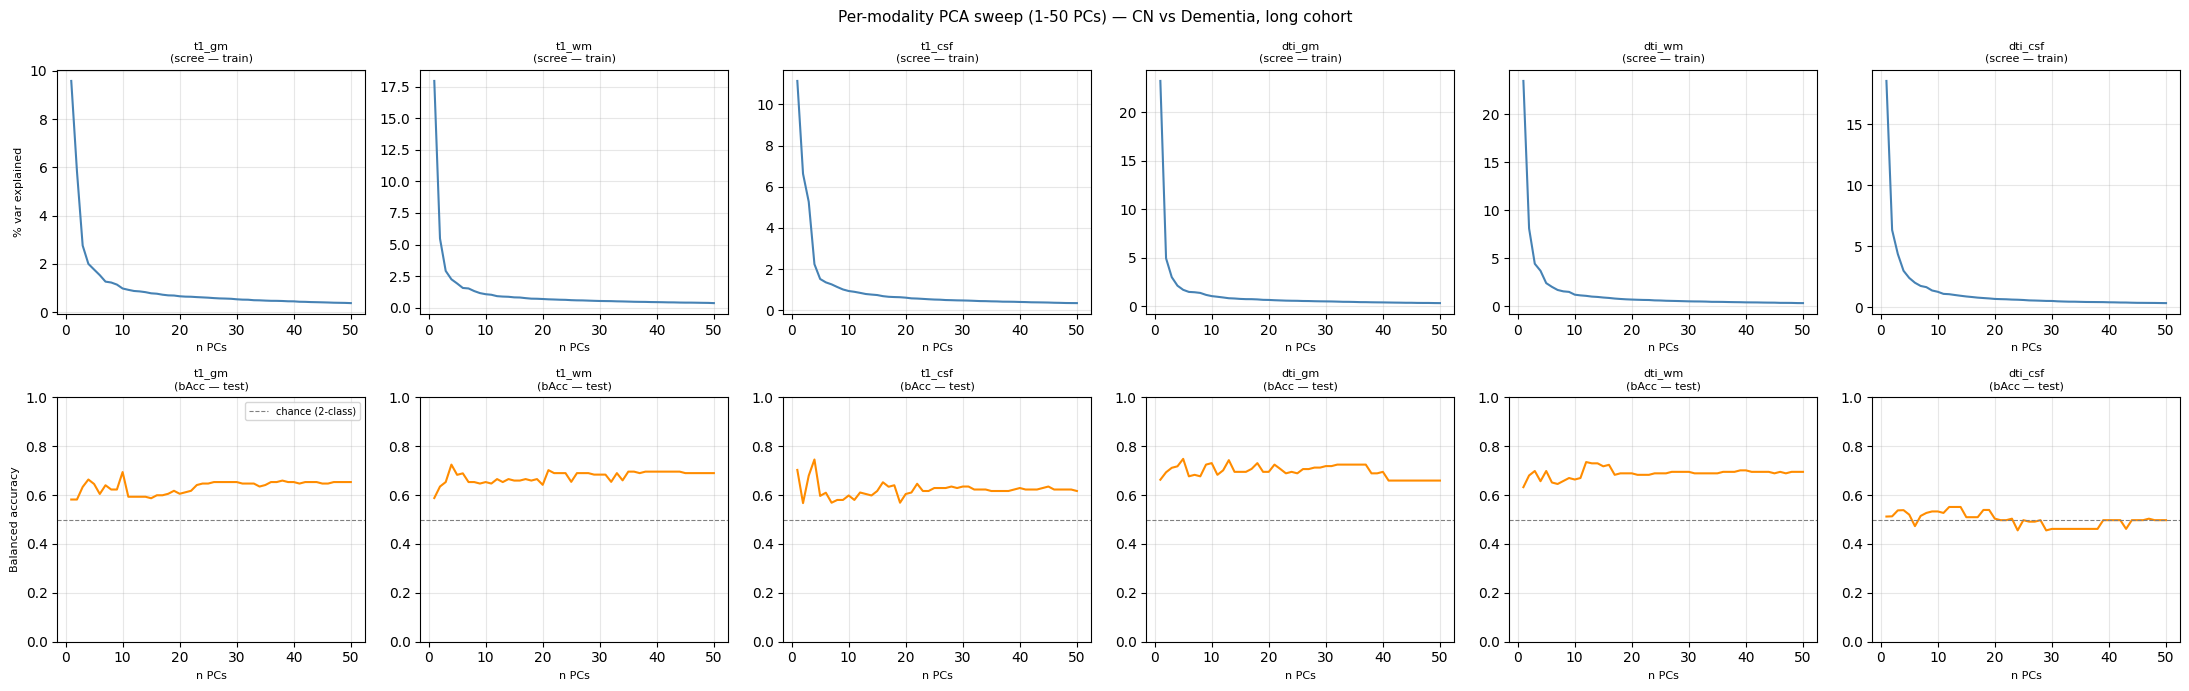

In [19]:
fig, axes = plt.subplots(2, 6, figsize=(22, 7))

for col, mod in enumerate(MODALITIES):
    sub_s = scree_df[scree_df["modality"] == mod]
    sub_b = bacc_df[bacc_df["modality"]  == mod]

    ax_s = axes[0, col]
    ax_s.plot(sub_s["n_pc"], sub_s["var_explained"] * 100, color="steelblue", lw=1.5)
    ax_s.set_title(f"{mod}\n(scree — train)", fontsize=8)
    ax_s.set_xlabel("n PCs", fontsize=8)
    ax_s.set_ylabel("% var explained" if col == 0 else "", fontsize=8)
    ax_s.grid(True, alpha=0.3)

    ax_b = axes[1, col]
    ax_b.plot(sub_b["n_pc"], sub_b["bAcc"], color="darkorange", lw=1.5)
    ax_b.axhline(0.5, color="grey", lw=0.8, ls="--", label="chance (2-class)")
    ax_b.set_xlabel("n PCs", fontsize=8)
    ax_b.set_ylabel("Balanced accuracy" if col == 0 else "", fontsize=8)
    ax_b.set_title(f"{mod}\n(bAcc — test)", fontsize=8)
    ax_b.set_ylim(0, 1)
    ax_b.grid(True, alpha=0.3)
    if col == 0:
        ax_b.legend(fontsize=7)

fig.suptitle(
    "Per-modality PCA sweep (1-50 PCs) — CN vs Dementia, long cohort",
    fontsize=11,
)
plt.tight_layout()
plt.show()


In [ ]:
#N_PC = 15
VAR_THRESHOLD = 0.2
tasks = {
    "CN vs Dementia":     meta["group"].isin(["CN", "Dementia"]),
    "CN vs MCI":          meta["group"].isin(["CN", "MCI"]),
    "CN vs MCI+Dementia": meta["group"].notna(),
}

print(f"{'Task':<22}  {'bAcc mean':>10}  {'bAcc std':>9}  {'n_test_min':>10}")
print("-" * 56)

for task_name, mask in tasks.items():
    sub  = meta[mask].reset_index(drop=True)
    y_t  = sub["group"].map({"CN": 0, "MCI": 1, "Dementia": 1}).values.astype(np.int64)
    grp  = sub["subject_id"].values
    idx  = np.where(mask.values)[0]
    Xs   = scalers["dti_gm"].transform(X_raw["dti_gm"].astype(np.float32))[idx]

    sgkf  = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)
    baccs = []
    fold_test_sizes = []
    for tr, te in sgkf.split(np.arange(len(y_t)), y_t, grp):
        pca = PCA(n_components=VAR_THRESHOLD, random_state=0).fit(Xs[tr])
        clf = SVC(class_weight="balanced", random_state=0).fit(pca.transform(Xs[tr]), y_t[tr])
        baccs.append(balanced_accuracy_score(y_t[te], clf.predict(pca.transform(Xs[te]))))
        fold_test_sizes.append((y_t[te] == 1).sum())  # minority class in test

    print(f"{task_name:<22}  {np.mean(baccs):>10.3f}  {np.std(baccs):>9.3f}  {min(fold_test_sizes):>10}  n_PC={pca.n_components_}")

Task                     bAcc mean   bAcc std  n_test_min
--------------------------------------------------------
CN vs Dementia               0.711      0.082          10  n_PC=2


In [ ]:
# --- VAR_THRESHOLD sweep across all modalities, CN vs Dementia ----------
VAR_THRESHOLD = 0.50
cd_mask = meta["group"].isin(["CN", "Dementia"])
sub_cd  = meta[cd_mask].reset_index(drop=True)
y_cd    = sub_cd["group"].map({"CN": 0, "Dementia": 1}).values.astype(np.int64)
grp_cd  = sub_cd["subject_id"].values
idx_cd  = np.where(cd_mask.values)[0]

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)

print(f"VAR_THRESHOLD={VAR_THRESHOLD}  |  CN vs Dementia")
print("{:<14}  {:>10}  {:>9}  {:>10}".format("Modality", "bAcc mean", "bAcc std", "n_PC range"))
print("-" * 50)

for mod in MODALITIES:
    Xs = scalers[mod].transform(X_raw[mod].astype(np.float32))[idx_cd]
    baccs, n_pcs = [], []
    for tr, te in sgkf.split(np.arange(len(y_cd)), y_cd, grp_cd):
        pca = PCA(n_components=VAR_THRESHOLD, random_state=0).fit(Xs[tr])
        clf = SVC(class_weight="balanced", random_state=0).fit(pca.transform(Xs[tr]), y_cd[tr])
        baccs.append(balanced_accuracy_score(y_cd[te], clf.predict(pca.transform(Xs[te]))))
        n_pcs.append(pca.n_components_)
    print(f"{mod:<14}  {np.mean(baccs):>10.3f}  {np.std(baccs):>9.3f}  {min(n_pcs)}-{max(n_pcs)}")


VAR_THRESHOLD=0.5  |  CN vs Dementia
Modality         bAcc mean   bAcc std  n_PC range
--------------------------------------------------
t1_gm                0.770      0.079  48-56
t1_wm                0.701      0.075  28-31
t1_csf               0.683      0.070  41-57
dti_gm               0.777      0.050  16-21


In [8]:
# --- 5-fold CV restricted to Siemens DTI subjects ----------------------------
N_PC = 15

scanner_df = pd.read_csv("model_data/adni/scanner_info_long.csv")
meta_sc = meta.merge(
    scanner_df,
    left_on=["subject_id", "t1_image_subject_id", "dti_image_subject_id"],
    right_on=["subject_id", "t1_id", "dti_id"],
    how="left"
)
meta_sc["dti_mfr"] = meta_sc["dti_scanner"].str.split("_").str[0]

# Boolean mask into meta/X_raw rows: Siemens DTI + valid diagnosis
siemens_mask = (meta_sc["dti_mfr"] == "Siemens") & meta_sc["group"].notna()
siemens_idx  = np.where(siemens_mask.values)[0]
meta_sc_s    = meta_sc[siemens_mask].reset_index(drop=True)

tasks = {
    "CN vs Dementia":     meta_sc_s["group"].isin(["CN", "Dementia"]),
    "CN vs MCI":          meta_sc_s["group"].isin(["CN", "MCI"]),
    "CN vs MCI+Dementia": pd.Series([True] * len(meta_sc_s)),
}

print(f"Siemens DTI subset: {len(meta_sc_s)} rows | "
      f"CN={( meta_sc_s['group']=='CN').sum()} "
      f"MCI={(meta_sc_s['group']=='MCI').sum()} "
      f"Dementia={(meta_sc_s['group']=='Dementia').sum()}")
print()

header = f"{'Modality':<14}  {'Task':<22}  {'bAcc':>6}  {'±':>5}  {'n_min':>5}"
print(header)
print("-" * len(header))

for mod in MODALITIES:
    Xs_full = scalers[mod].transform(X_raw[mod].astype(np.float32))
    Xs_s    = Xs_full[siemens_idx]          # rows for Siemens subjects only

    for task_name, task_mask in tasks.items():
        sub_idx = np.where(task_mask.values)[0]
        Xs_t    = Xs_s[sub_idx]
        y_t     = meta_sc_s.loc[task_mask, "group"].map(
                      {"CN": 0, "MCI": 1, "Dementia": 1}).values.astype(np.int64)
        grp_t   = meta_sc_s.loc[task_mask, "subject_id"].values

        sgkf  = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)
        baccs, mins = [], []
        for tr, te in sgkf.split(np.arange(len(y_t)), y_t, grp_t):
            pca = PCA(n_components=N_PC, random_state=0,
                      svd_solver="randomized").fit(Xs_t[tr])
            clf = SVC(class_weight="balanced", random_state=0).fit(
                      pca.transform(Xs_t[tr]), y_t[tr])
            baccs.append(balanced_accuracy_score(
                      y_t[te], clf.predict(pca.transform(Xs_t[te]))))
            mins.append((y_t[te] == 1).sum())

        print(f"{mod:<14}  {task_name:<22}  "
              f"{np.mean(baccs):>6.3f}  {np.std(baccs):>5.3f}  {min(mins):>5}")
    print()

Siemens DTI subset: 667 rows | CN=363 MCI=232 Dementia=72

Modality        Task                      bAcc      ±  n_min
------------------------------------------------------------
t1_gm           CN vs Dementia           0.778  0.039      9
t1_gm           CN vs MCI                0.671  0.050     28
t1_gm           CN vs MCI+Dementia       0.695  0.060     50

t1_wm           CN vs Dementia           0.693  0.059      9
t1_wm           CN vs MCI                0.631  0.039     28
t1_wm           CN vs MCI+Dementia       0.675  0.069     50

t1_csf          CN vs Dementia           0.667  0.063      9
t1_csf          CN vs MCI                0.622  0.048     28
t1_csf          CN vs MCI+Dementia       0.639  0.062     50

dti_gm          CN vs Dementia           0.772  0.068      9
dti_gm          CN vs MCI                0.633  0.033     28
dti_gm          CN vs MCI+Dementia       0.693  0.044     50

dti_wm          CN vs Dementia           0.823  0.055      9
dti_wm          CN vs 

In [11]:
# --- 5-fold CV restricted to Siemens + GE DTI subjects -----------------------
# Requires meta_sc / scalers from cells above
N_PC = 15

sg_mask  = (meta_sc["dti_mfr"].isin(["Siemens", "GE"])) & meta_sc["group"].notna()
sg_idx   = np.where(sg_mask.values)[0]
meta_sc_sg = meta_sc[sg_mask].reset_index(drop=True)

tasks = {
    "CN vs Dementia":     meta_sc_sg["group"].isin(["CN", "Dementia"]),
    "CN vs MCI":          meta_sc_sg["group"].isin(["CN", "MCI"]),
    "CN vs MCI+Dementia": pd.Series([True] * len(meta_sc_sg)),
}

print(f"Siemens+GE DTI subset: {len(meta_sc_sg)} rows | "
      f"CN={(meta_sc_sg['group']=='CN').sum()} "
      f"MCI={(meta_sc_sg['group']=='MCI').sum()} "
      f"Dementia={(meta_sc_sg['group']=='Dementia').sum()}")
print()

header = f"{'Modality':<14}  {'Task':<22}  {'bAcc':>6}  {'\xb1':>5}  {'n_min':>5}"
print(header)
print("-" * len(header))

for mod in MODALITIES:
    Xs_full = scalers[mod].transform(X_raw[mod].astype(np.float32))
    Xs_sg   = Xs_full[sg_idx]

    for task_name, task_mask in tasks.items():
        sub_idx = np.where(task_mask.values)[0]
        Xs_t    = Xs_sg[sub_idx]
        y_t     = meta_sc_sg.loc[task_mask, "group"].map(
                      {"CN": 0, "MCI": 1, "Dementia": 1}).values.astype(np.int64)
        grp_t   = meta_sc_sg.loc[task_mask, "subject_id"].values

        sgkf  = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)
        baccs, mins = [], []
        for tr, te in sgkf.split(np.arange(len(y_t)), y_t, grp_t):
            pca = PCA(n_components=N_PC, random_state=0,
                      svd_solver="randomized").fit(Xs_t[tr])
            clf = SVC(class_weight="balanced", random_state=0).fit(
                      pca.transform(Xs_t[tr]), y_t[tr])
            baccs.append(balanced_accuracy_score(
                      y_t[te], clf.predict(pca.transform(Xs_t[te]))))
            mins.append((y_t[te] == 1).sum())

        print(f"{mod:<14}  {task_name:<22}  "
              f"{np.mean(baccs):>6.3f}  {np.std(baccs):>5.3f}  {min(mins):>5}")
    print()


Siemens+GE DTI subset: 725 rows | CN=383 MCI=267 Dementia=75

Modality        Task                      bAcc      ±  n_min
------------------------------------------------------------
t1_gm           CN vs Dementia           0.779  0.120      8
t1_gm           CN vs MCI                0.637  0.035     38
t1_gm           CN vs MCI+Dementia       0.679  0.020     58

t1_wm           CN vs Dementia           0.639  0.106      8
t1_wm           CN vs MCI                0.621  0.025     38
t1_wm           CN vs MCI+Dementia       0.670  0.022     58

t1_csf          CN vs Dementia           0.705  0.061      8
t1_csf          CN vs MCI                0.615  0.054     38
t1_csf          CN vs MCI+Dementia       0.640  0.043     58

dti_gm          CN vs Dementia           0.738  0.111      8
dti_gm          CN vs MCI                0.637  0.058     38
dti_gm          CN vs MCI+Dementia       0.674  0.028     58

dti_wm          CN vs Dementia           0.766  0.080      8
dti_wm          CN 

In [21]:
# --- 5-fold CV restricted to Siemens + Philips DTI subjects ------------------
# Requires meta_sc / scalers from cells above
N_PC = 15

sp_mask  = (meta_sc["dti_mfr"].isin(["Siemens", "Philips"])) & meta_sc["group"].notna()
sp_idx   = np.where(sp_mask.values)[0]
meta_sc_sp = meta_sc[sp_mask].reset_index(drop=True)

tasks = {
    "CN vs Dementia":     meta_sc_sp["group"].isin(["CN", "Dementia"]),
    "CN vs MCI":          meta_sc_sp["group"].isin(["CN", "MCI"]),
    "CN vs MCI+Dementia": pd.Series([True] * len(meta_sc_sp)),
}

print(f"Siemens+Philips DTI subset: {len(meta_sc_sp)} rows | "
      f"CN={(meta_sc_sp['group']=='CN').sum()} "
      f"MCI={(meta_sc_sp['group']=='MCI').sum()} "
      f"Dementia={(meta_sc_sp['group']=='Dementia').sum()}")
print()

header = f"{'Modality':<14}  {'Task':<22}  {'bAcc':>6}  {'\xb1':>5}  {'n_min':>5}"
print(header)
print("-" * len(header))

for mod in MODALITIES:
    Xs_full = scalers[mod].transform(X_raw[mod].astype(np.float32))
    Xs_sp   = Xs_full[sp_idx]

    for task_name, task_mask in tasks.items():
        sub_idx = np.where(task_mask.values)[0]
        Xs_t    = Xs_sp[sub_idx]
        y_t     = meta_sc_sp.loc[task_mask, "group"].map(
                      {"CN": 0, "MCI": 1, "Dementia": 1}).values.astype(np.int64)
        grp_t   = meta_sc_sp.loc[task_mask, "subject_id"].values

        sgkf  = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)
        baccs, mins = [], []
        for tr, te in sgkf.split(np.arange(len(y_t)), y_t, grp_t):
            pca = PCA(n_components=N_PC, random_state=0,
                      svd_solver="randomized").fit(Xs_t[tr])
            clf = SVC(class_weight="balanced", random_state=0).fit(
                      pca.transform(Xs_t[tr]), y_t[tr])
            baccs.append(balanced_accuracy_score(
                      y_t[te], clf.predict(pca.transform(Xs_t[te]))))
            mins.append((y_t[te] == 1).sum())

        print(f"{mod:<14}  {task_name:<22}  "
              f"{np.mean(baccs):>6.3f}  {np.std(baccs):>5.3f}  {min(mins):>5}")
    print()


Siemens+Philips DTI subset: 712 rows | CN=391 MCI=247 Dementia=74

Modality        Task                      bAcc      ±  n_min
------------------------------------------------------------
t1_gm           CN vs Dementia           0.753  0.094     11
t1_gm           CN vs MCI                0.667  0.080     45
t1_gm           CN vs MCI+Dementia       0.696  0.022     50

t1_wm           CN vs Dementia           0.666  0.067     11
t1_wm           CN vs MCI                0.628  0.027     45
t1_wm           CN vs MCI+Dementia       0.653  0.041     50

t1_csf          CN vs Dementia           0.693  0.060     11
t1_csf          CN vs MCI                0.607  0.037     45
t1_csf          CN vs MCI+Dementia       0.644  0.040     50

dti_gm          CN vs Dementia           0.742  0.084     11
dti_gm          CN vs MCI                0.632  0.058     45
dti_gm          CN vs MCI+Dementia       0.672  0.048     50

dti_wm          CN vs Dementia           0.826  0.062     11
dti_wm        

In [16]:
# --- 5-fold CV all DTI manufacturers (Siemens + GE + Philips) ----------------
# Requires meta_sc / scalers from cells above
N_PC = 15

all_mask  = meta_sc["group"].notna()
all_idx   = np.where(all_mask.values)[0]
meta_sc_all = meta_sc[all_mask].reset_index(drop=True)

tasks = {
    "CN vs Dementia":     meta_sc_all["group"].isin(["CN", "Dementia"]),
    "CN vs MCI":          meta_sc_all["group"].isin(["CN", "MCI"]),
    "CN vs MCI+Dementia": pd.Series([True] * len(meta_sc_all)),
}

print(f"All manufacturers subset: {len(meta_sc_all)} rows | "
      f"CN={(meta_sc_all['group']=='CN').sum()} "
      f"MCI={(meta_sc_all['group']=='MCI').sum()} "
      f"Dementia={(meta_sc_all['group']=='Dementia').sum()}")
mfr_counts = meta_sc_all["dti_mfr"].value_counts()
print("DTI manufacturer breakdown:", mfr_counts.to_dict())
print()

header = f"{'Modality':<14}  {'Task':<22}  {'bAcc':>6}  {chr(177):>5}  {'n_min':>5}"
print(header)
print("-" * len(header))

for mod in MODALITIES:
    Xs_full  = scalers[mod].transform(X_raw[mod].astype(np.float32))
    Xs_all   = Xs_full[all_idx]

    for task_name, task_mask in tasks.items():
        sub_idx = np.where(task_mask.values)[0]
        Xs_t    = Xs_all[sub_idx]
        y_t     = meta_sc_all.loc[task_mask, "group"].map(
                      {"CN": 0, "MCI": 1, "Dementia": 1}).values.astype(np.int64)
        grp_t   = meta_sc_all.loc[task_mask, "subject_id"].values

        sgkf  = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)
        baccs, mins = [], []
        for tr, te in sgkf.split(np.arange(len(y_t)), y_t, grp_t):
            pca = PCA(n_components=N_PC, random_state=0,
                      svd_solver="randomized").fit(Xs_t[tr])
            #clf = SVC(class_weight="balanced", random_state=0).fit(
            #          pca.transform(Xs_t[tr]), y_t[tr])
            X_pc_tr = pca.transform(Xs_t[tr])
            #X_res, y_res = RandomUnderSampler(random_state=0).fit_resample(X_pc_tr, y_t[tr])
            X_res, y_res = SMOTE(random_state=0).fit_resample(X_pc_tr, y_t[tr])
            clf = SVC(random_state=0).fit(X_res, y_res)
            baccs.append(balanced_accuracy_score(
                      y_t[te], clf.predict(pca.transform(Xs_t[te]))))
            mins.append((y_t[te] == 1).sum())

        print(f"{mod:<14}  {task_name:<22}  "
              f"{np.mean(baccs):>6.3f}  {np.std(baccs):>5.3f}  {min(mins):>5}")
    print()


All manufacturers subset: 770 rows | CN=411 MCI=282 Dementia=77
DTI manufacturer breakdown: {'Siemens': 667, 'GE': 58, 'Philips': 45}

Modality        Task                      bAcc      ±  n_min
------------------------------------------------------------
t1_gm           CN vs Dementia           0.754  0.092     10
t1_gm           CN vs MCI                0.641  0.041     39
t1_gm           CN vs MCI+Dementia       0.692  0.051     58

t1_wm           CN vs Dementia           0.664  0.045     10
t1_wm           CN vs MCI                0.618  0.043     39
t1_wm           CN vs MCI+Dementia       0.659  0.034     58

t1_csf          CN vs Dementia           0.646  0.070     10
t1_csf          CN vs MCI                0.599  0.036     39
t1_csf          CN vs MCI+Dementia       0.660  0.035     58

dti_gm          CN vs Dementia           0.739  0.077     10
dti_gm          CN vs MCI                0.620  0.051     39
dti_gm          CN vs MCI+Dementia       0.650  0.021     58

dti_wm 

In [21]:
# --- Scanner-stratified 80/20 split vs. pooled 80/20 split (bias diagnostic) -
# Condition 1: random 80/20 split ignoring scanner (train_test_split, stratified by label+group)
# Condition 2: 80% of each scanner manufacturer's subjects → train, 20% → test
# Difference in bAcc reveals whether pooled CV benefits from scanner imbalance across folds.
# Requires meta_sc_all, all_idx, scalers from cells above.
N_PC = 15
RNG  = np.random.default_rng(0)

tasks = {
    "CN vs Dementia":     meta_sc_all["group"].isin(["CN", "Dementia"]),
    "CN vs MCI":          meta_sc_all["group"].isin(["CN", "MCI"]),
    "CN vs MCI+Dementia": pd.Series([True] * len(meta_sc_all)),
}

header = f"{'Modality':<14}  {'Task':<22}  {'cond1_bAcc':>10}  {'cond2_bAcc':>10}  {'delta':>7}"
print(header)
print("-" * len(header))

for mod in MODALITIES:
    Xs_full = scalers[mod].transform(X_raw[mod].astype(np.float32))
    Xs_all  = Xs_full[all_idx]

    for task_name, task_mask in tasks.items():
        sub_idx = np.where(task_mask.values)[0]
        Xs_t    = Xs_all[sub_idx]
        meta_t  = meta_sc_all[task_mask].reset_index(drop=True)
        y_t     = meta_t["group"].map({"CN": 0, "MCI": 1, "Dementia": 1}).values.astype(np.int64)

        # --- Condition 1: random 80/20 (one split, stratified by label) ------
        c1_baccs = []
        for seed in range(5):
            tr1, te1 = train_test_split(
                np.arange(len(y_t)), test_size=0.2,
                stratify=y_t, random_state=seed)
            pca = PCA(n_components=N_PC, random_state=0, svd_solver="randomized").fit(Xs_t[tr1])
            clf = SVC(class_weight="balanced", random_state=0).fit(
                      pca.transform(Xs_t[tr1]), y_t[tr1])
            c1_baccs.append(balanced_accuracy_score(
                      y_t[te1], clf.predict(pca.transform(Xs_t[te1]))))
        c1 = np.mean(c1_baccs)

        # --- Condition 2: scanner-stratified 80/20 (80% of each mfr → train) -
        c2_baccs = []
        for seed in range(5):
            tr2_list, te2_list = [], []
            for mfr, grp_df in meta_t.groupby("dti_mfr"):
                mfr_idx = grp_df.index.values
                n_te    = max(1, int(round(len(mfr_idx) * 0.2)))
                rng_seed = np.random.default_rng(seed)
                perm     = rng_seed.permutation(len(mfr_idx))
                te2_list.append(mfr_idx[perm[:n_te]])
                tr2_list.append(mfr_idx[perm[n_te:]])
            tr2 = np.concatenate(tr2_list)
            te2 = np.concatenate(te2_list)
            if len(np.unique(y_t[te2])) < 2:
                continue
            pca = PCA(n_components=N_PC, random_state=0, svd_solver="randomized").fit(Xs_t[tr2])
            clf = SVC(class_weight="balanced", random_state=0).fit(
                      pca.transform(Xs_t[tr2]), y_t[tr2])
            c2_baccs.append(balanced_accuracy_score(
                      y_t[te2], clf.predict(pca.transform(Xs_t[te2]))))
        c2 = np.mean(c2_baccs)

        print(f"{mod:<14}  {task_name:<22}  {c1:>10.3f}  {c2:>10.3f}  {c2-c1:>+7.3f}")
    print()


Modality        Task                    cond1_bAcc  cond2_bAcc    delta
-----------------------------------------------------------------------
t1_gm           CN vs Dementia               0.835       0.789   -0.046
t1_gm           CN vs MCI                    0.711       0.740   +0.029
t1_gm           CN vs MCI+Dementia           0.730       0.710   -0.020

t1_wm           CN vs Dementia               0.782       0.699   -0.083
t1_wm           CN vs MCI                    0.687       0.706   +0.019
t1_wm           CN vs MCI+Dementia           0.706       0.714   +0.008

t1_csf          CN vs Dementia               0.745       0.712   -0.033
t1_csf          CN vs MCI                    0.703       0.708   +0.005
t1_csf          CN vs MCI+Dementia           0.703       0.692   -0.011

dti_gm          CN vs Dementia               0.798       0.766   -0.033
dti_gm          CN vs MCI                    0.673       0.690   +0.017
dti_gm          CN vs MCI+Dementia           0.716       0.67

In [22]:
# --- CN Amy− vs Dem Amy+ : 5-fold CV, all manufacturers, random undersampling ---
# Unimodal + early-fusion (PCA concat) sections.
# Reuses meta_joint / joint_idx / scalers from the OvA setup cell.
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import confusion_matrix

N_PC = 15

# Build binary task: CN Amy− = 0, Dem Amy+ = 1
cna_dem_mask = (
    (meta_joint["group"].eq("CN")       & (meta_joint["amyloid_label"] == 0.0)) |
    (meta_joint["group"].eq("Dementia") & (meta_joint["amyloid_label"] == 1.0))
)
meta_cda       = meta_joint[cna_dem_mask].reset_index(drop=True)
cda_local_idx  = np.where(cna_dem_mask.values)[0]
cda_global_idx = joint_idx[cda_local_idx]

y_cda   = meta_cda["group"].map({"CN": 0, "Dementia": 1}).values.astype(np.int64)
grp_cda = meta_cda["subject_id"].values

n_cn  = (y_cda == 0).sum()
n_dem = (y_cda == 1).sum()
print(f"CN Amy− vs Dem Amy+  |  all manufacturers  |  CN Amy−={n_cn}  Dem Amy+={n_dem}  ratio={n_cn/n_dem:.1f}:1")
print()

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)
rus  = RandomUnderSampler(random_state=0)

def _eval_fold(X_tr, X_te, y_tr, y_te):
    X_res, y_res = rus.fit_resample(X_tr, y_tr)
    clf    = SVC(random_state=0).fit(X_res, y_res)
    y_pred = clf.predict(X_te)
    tn, fp, fn, tp = confusion_matrix(y_te, y_pred, labels=[0, 1]).ravel()
    bacc = balanced_accuracy_score(y_te, y_pred)
    sens = tp / (tp + fn) if (tp + fn) else np.nan
    spec = tn / (tn + fp) if (tn + fp) else np.nan
    n_min = int((y_te == 1).sum())
    return bacc, sens, spec, n_min

def _print_row(label, baccs, senss, specs, mins, width=20):
    print(f"{label:<{width}}  {np.mean(baccs):>6.3f}  {np.std(baccs):>5.3f}  "
          f"{np.nanmean(senss):>6.3f}  {np.nanmean(specs):>6.3f}  {min(mins):>5}")

header = f"{'Model':<20}  {'bAcc':>6}  {chr(177):>5}  {'Sens':>6}  {'Spec':>6}  {'n_min':>5}"
print("── Unimodal " + "─" * (len(header) - 11))
print(header)
print("-" * len(header))

# ── Unimodal ─────────────────────────────────────────────────────────────────
for mod in MODALITIES:
    Xs_mod = scalers[mod].transform(X_raw[mod].astype(np.float32))[cda_global_idx]
    baccs, senss, specs, mins = [], [], [], []
    for tr, te in sgkf.split(np.arange(len(y_cda)), y_cda, grp_cda):
        pca = PCA(n_components=N_PC, random_state=0, svd_solver="randomized").fit(Xs_mod[tr])
        b, se, sp, m = _eval_fold(pca.transform(Xs_mod[tr]), pca.transform(Xs_mod[te]),
                                   y_cda[tr], y_cda[te])
        baccs.append(b); senss.append(se); specs.append(sp); mins.append(m)
    _print_row(mod, baccs, senss, specs, mins)

# ── Early fusion (PCA concat) ─────────────────────────────────────────────────
FUSION_GROUPS = {
    "t1_gm + dti_gm":    ["t1_gm", "dti_gm"],
    "t1_wm + dti_wm":    ["t1_wm", "dti_wm"],
    "t1_gm + dti_wm":    ["t1_gm", "dti_wm"],
    "all T1":             ["t1_gm", "t1_wm", "t1_csf"],
    "all DTI":            ["dti_gm", "dti_wm", "dti_csf"],
    "all 6 modalities":   ["t1_gm", "t1_wm", "t1_csf", "dti_gm", "dti_wm", "dti_csf"],
}

print()
print("── Early fusion (PCA concat) " + "─" * (len(header) - 28))
print(header)
print("-" * len(header))

for fusion_name, mods in FUSION_GROUPS.items():
    Xs_by_mod = {
        mod: scalers[mod].transform(X_raw[mod].astype(np.float32))[cda_global_idx]
        for mod in mods
    }
    baccs, senss, specs, mins = [], [], [], []
    for tr, te in sgkf.split(np.arange(len(y_cda)), y_cda, grp_cda):
        tr_parts, te_parts = [], []
        for mod in mods:
            pca = PCA(n_components=N_PC, random_state=0, svd_solver="randomized").fit(Xs_by_mod[mod][tr])
            tr_parts.append(pca.transform(Xs_by_mod[mod][tr]))
            te_parts.append(pca.transform(Xs_by_mod[mod][te]))
        b, se, sp, m = _eval_fold(np.concatenate(tr_parts, axis=1),
                                   np.concatenate(te_parts, axis=1),
                                   y_cda[tr], y_cda[te])
        baccs.append(b); senss.append(se); specs.append(sp); mins.append(m)
    _print_row(fusion_name, baccs, senss, specs, mins)


CN Amy− vs Dem Amy+  |  all manufacturers  |  CN Amy−=222  Dem Amy+=50  ratio=4.4:1

── Unimodal ───────────────────────────────────────────────
Model                   bAcc      ±    Sens    Spec  n_min
----------------------------------------------------------
t1_gm                  0.769  0.044   0.618   0.920      3
t1_wm                  0.780  0.085   0.733   0.826      3
t1_csf                 0.663  0.061   0.592   0.734      3
dti_gm                 0.769  0.117   0.706   0.832      3
dti_wm                 0.772  0.069   0.732   0.813      3
dti_csf                0.689  0.081   0.635   0.743      3

── Early fusion (PCA concat) ──────────────────────────────
Model                   bAcc      ±    Sens    Spec  n_min
----------------------------------------------------------
t1_gm + dti_gm         0.800  0.099   0.711   0.889      3
t1_wm + dti_wm         0.780  0.096   0.715   0.844      3
t1_gm + dti_wm         0.815  0.073   0.725   0.905      3
all T1                 0.76

In [12]:
# --- Multimodal early fusion 5-fold CV, all manufacturers -------------------
# Early fusion: per-modality PCA features concatenated, single SVM trained on joint space.
# Reuses meta_sc_all, all_idx, scalers from cells above.
N_PC = 15

FUSION_GROUPS = {
    "t1_gm + dti_wm":  ["t1_gm", "dti_wm"],
    "all T1":           ["t1_gm", "t1_wm", "t1_csf"],
    "all DTI":          ["dti_gm", "dti_wm", "dti_csf"],
    "all 6 modalities": ["t1_gm", "t1_wm", "t1_csf", "dti_gm", "dti_wm", "dti_csf"],
    # same-tissue, cross-modality pairs
    "t1_gm + dti_gm":  ["t1_gm", "dti_gm"],
    "t1_wm + dti_wm":  ["t1_wm", "dti_wm"],
    "t1_csf + dti_csf": ["t1_csf", "dti_csf"],
    # tissue-focused subsets (GM+WM only)
    "T1 gm+wm":        ["t1_gm", "t1_wm"],
    "DTI gm+wm":       ["dti_gm", "dti_wm"],
    "gm+wm both mod":  ["t1_gm", "t1_wm", "dti_gm", "dti_wm"],
}

fusion_tasks = {
    "CN vs Dementia":     meta_sc_all["group"].isin(["CN", "Dementia"]),
    "CN vs MCI":          meta_sc_all["group"].isin(["CN", "MCI"]),
    "CN vs MCI+Dementia": pd.Series([True] * len(meta_sc_all)),
}

header = f"{'Fusion':<20}  {'Task':<22}  {'bAcc':>6}  {chr(177):>5}  {'n_min':>5}"
print(header)
print("-" * len(header))

for fusion_name, mods in FUSION_GROUPS.items():
    for task_name, task_mask in fusion_tasks.items():
        sub_idx = np.where(task_mask.values)[0]
        y_t   = meta_sc_all.loc[task_mask, "group"].map(
                    {"CN": 0, "MCI": 1, "Dementia": 1}).values.astype(np.int64)
        grp_t = meta_sc_all.loc[task_mask, "subject_id"].values

        # Pre-scale and subset features for each modality
        Xs_by_mod = {
            mod: scalers[mod].transform(X_raw[mod].astype(np.float32))[all_idx][sub_idx]
            for mod in mods
        }

        sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)
        baccs, mins = [], []
        for tr, te in sgkf.split(np.arange(len(y_t)), y_t, grp_t):
            train_parts, test_parts = [], []
            for mod in mods:
                Xs_t = Xs_by_mod[mod]
                pca  = PCA(n_components=N_PC, random_state=0,
                           svd_solver="randomized").fit(Xs_t[tr])
                train_parts.append(pca.transform(Xs_t[tr]))
                test_parts.append(pca.transform(Xs_t[te]))

            X_train = np.concatenate(train_parts, axis=1)
            X_test  = np.concatenate(test_parts,  axis=1)

            clf    = SVC(class_weight="balanced", random_state=0).fit(X_train, y_t[tr])
            y_pred = clf.predict(X_test)
            baccs.append(balanced_accuracy_score(y_t[te], y_pred))
            mins.append((y_t[te] == 1).sum())

        print(f"{fusion_name:<20}  {task_name:<22}  "
              f"{np.mean(baccs):>6.3f}  {np.std(baccs):>5.3f}  {min(mins):>5}")
    print()

Fusion                Task                      bAcc      ±  n_min
------------------------------------------------------------------
t1_gm + dti_wm        CN vs Dementia           0.767  0.061     10
t1_gm + dti_wm        CN vs MCI                0.629  0.041     39
t1_gm + dti_wm        CN vs MCI+Dementia       0.693  0.048     58

all T1                CN vs Dementia           0.732  0.083     10
all T1                CN vs MCI                0.628  0.050     39
all T1                CN vs MCI+Dementia       0.688  0.043     58

all DTI               CN vs Dementia           0.774  0.062     10
all DTI               CN vs MCI                0.624  0.037     39
all DTI               CN vs MCI+Dementia       0.673  0.034     58

all 6 modalities      CN vs Dementia           0.764  0.097     10
all 6 modalities      CN vs MCI                0.639  0.059     39
all 6 modalities      CN vs MCI+Dementia       0.700  0.035     58

t1_gm + dti_gm        CN vs Dementia           0.755  0.08

In [22]:
# --- Multimodal score fusion 5-fold CV, Siemens only ------------------------
# Reuses meta_sc_s, siemens_idx, scalers from cells above.
N_PC = 15

fusion_tasks_s = {
    "CN vs Dementia":     meta_sc_s["group"].isin(["CN", "Dementia"]),
    "CN vs MCI":          meta_sc_s["group"].isin(["CN", "MCI"]),
    "CN vs MCI+Dementia": pd.Series([True] * len(meta_sc_s)),
}

header = f"{'Fusion':<20}  {'Task':<22}  {'bAcc':>6}  {chr(177):>5}  {'n_min':>5}"
print(header)
print("-" * len(header))

for fusion_name, mods in FUSION_GROUPS.items():
    for task_name, task_mask in fusion_tasks_s.items():
        sub_idx = np.where(task_mask.values)[0]
        y_t   = meta_sc_s.loc[task_mask, "group"].map(
                    {"CN": 0, "MCI": 1, "Dementia": 1}).values.astype(np.int64)
        grp_t = meta_sc_s.loc[task_mask, "subject_id"].values

        Xs_by_mod = {
            mod: scalers[mod].transform(X_raw[mod].astype(np.float32))[siemens_idx][sub_idx]
            for mod in mods
        }

        sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)
        baccs, mins = [], []
        for tr, te in sgkf.split(np.arange(len(y_t)), y_t, grp_t):
            fold_scores = np.zeros(len(te))
            for mod in mods:
                Xs_t = Xs_by_mod[mod]
                pca  = PCA(n_components=N_PC, random_state=0,
                           svd_solver="randomized").fit(Xs_t[tr])
                clf  = SVC(class_weight="balanced", random_state=0).fit(
                           pca.transform(Xs_t[tr]), y_t[tr])
                fold_scores += clf.decision_function(pca.transform(Xs_t[te]))
            y_pred = (fold_scores > 0).astype(int)
            baccs.append(balanced_accuracy_score(y_t[te], y_pred))
            mins.append((y_t[te] == 1).sum())

        print(f"{fusion_name:<20}  {task_name:<22}  "
              f"{np.mean(baccs):>6.3f}  {np.std(baccs):>5.3f}  {min(mins):>5}")
    print()


Fusion                Task                      bAcc      ±  n_min
------------------------------------------------------------------
t1_gm + dti_wm        CN vs Dementia           0.824  0.046      9
t1_gm + dti_wm        CN vs MCI                0.668  0.040     28
t1_gm + dti_wm        CN vs MCI+Dementia       0.712  0.048     50

all T1                CN vs Dementia           0.755  0.076      9
all T1                CN vs MCI                0.668  0.022     28
all T1                CN vs MCI+Dementia       0.689  0.067     50

all DTI               CN vs Dementia           0.754  0.081      9
all DTI               CN vs MCI                0.649  0.031     28
all DTI               CN vs MCI+Dementia       0.692  0.054     50

all 6 modalities      CN vs Dementia           0.777  0.048      9
all 6 modalities      CN vs MCI                0.661  0.033     28
all 6 modalities      CN vs MCI+Dementia       0.687  0.045     50



In [8]:
# --- Amyloid +/- scree plot (all subjects with valid amyloid label) -----------
# Stage 2 of two-stage pipeline: after CN vs AD, classify amyloid +/-
amy_mask   = meta["amyloid_label"].notna().values
y_amy      = meta.loc[amy_mask, "amyloid_label"].astype(int).values   # 0=amy-, 1=amy+
idx_amy    = np.where(amy_mask)[0]
groups_amy = meta.loc[amy_mask, "subject_id"].values

print(f"Amyloid subset: {amy_mask.sum()} subjects | "
      f"amy-={(y_amy==0).sum()}  amy+={(y_amy==1).sum()}")

sgkf_amy = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)
amy_tr, amy_te = next(sgkf_amy.split(np.arange(len(y_amy)), y_amy, groups_amy))
y_amy_tr, y_amy_te = y_amy[amy_tr], y_amy[amy_te]

print(f"Train: amy-={(y_amy_tr==0).sum()}  amy+={(y_amy_tr==1).sum()}")
print(f"Test:  amy-={(y_amy_te==0).sum()}  amy+={(y_amy_te==1).sum()}")
print()

amy_scree_records, amy_bacc_records = [], []

for mod in MODALITIES:
    Xs_full = scalers[mod].transform(X_raw[mod].astype(np.float32))
    Xb      = Xs_full[idx_amy]
    Xb_tr   = Xb[amy_tr]
    Xb_te   = Xb[amy_te]

    pca = PCA(n_components=50, random_state=0, svd_solver="randomized").fit(Xb_tr)
    evr = pca.explained_variance_ratio_
    Z_tr = pca.transform(Xb_tr)
    Z_te = pca.transform(Xb_te)

    for n_pc in range(1, 51):
        amy_scree_records.append({"modality": mod, "n_pc": n_pc,
                                   "var_explained": float(evr[n_pc - 1])})
        clf  = SVC(class_weight="balanced", random_state=0).fit(Z_tr[:, :n_pc], y_amy_tr)
        bacc = balanced_accuracy_score(y_amy_te, clf.predict(Z_te[:, :n_pc]))
        amy_bacc_records.append({"modality": mod, "n_pc": n_pc, "bAcc": float(bacc)})

    print(f"  {mod} done")

amy_scree_df = pd.DataFrame(amy_scree_records)
amy_bacc_df  = pd.DataFrame(amy_bacc_records)

Amyloid subset: 723 subjects | amy-=387  amy+=336
Train: amy-=302  amy+=270
Test:  amy-=85  amy+=66

  t1_gm done
  t1_wm done
  t1_csf done
  dti_gm done
  dti_wm done
  dti_csf done


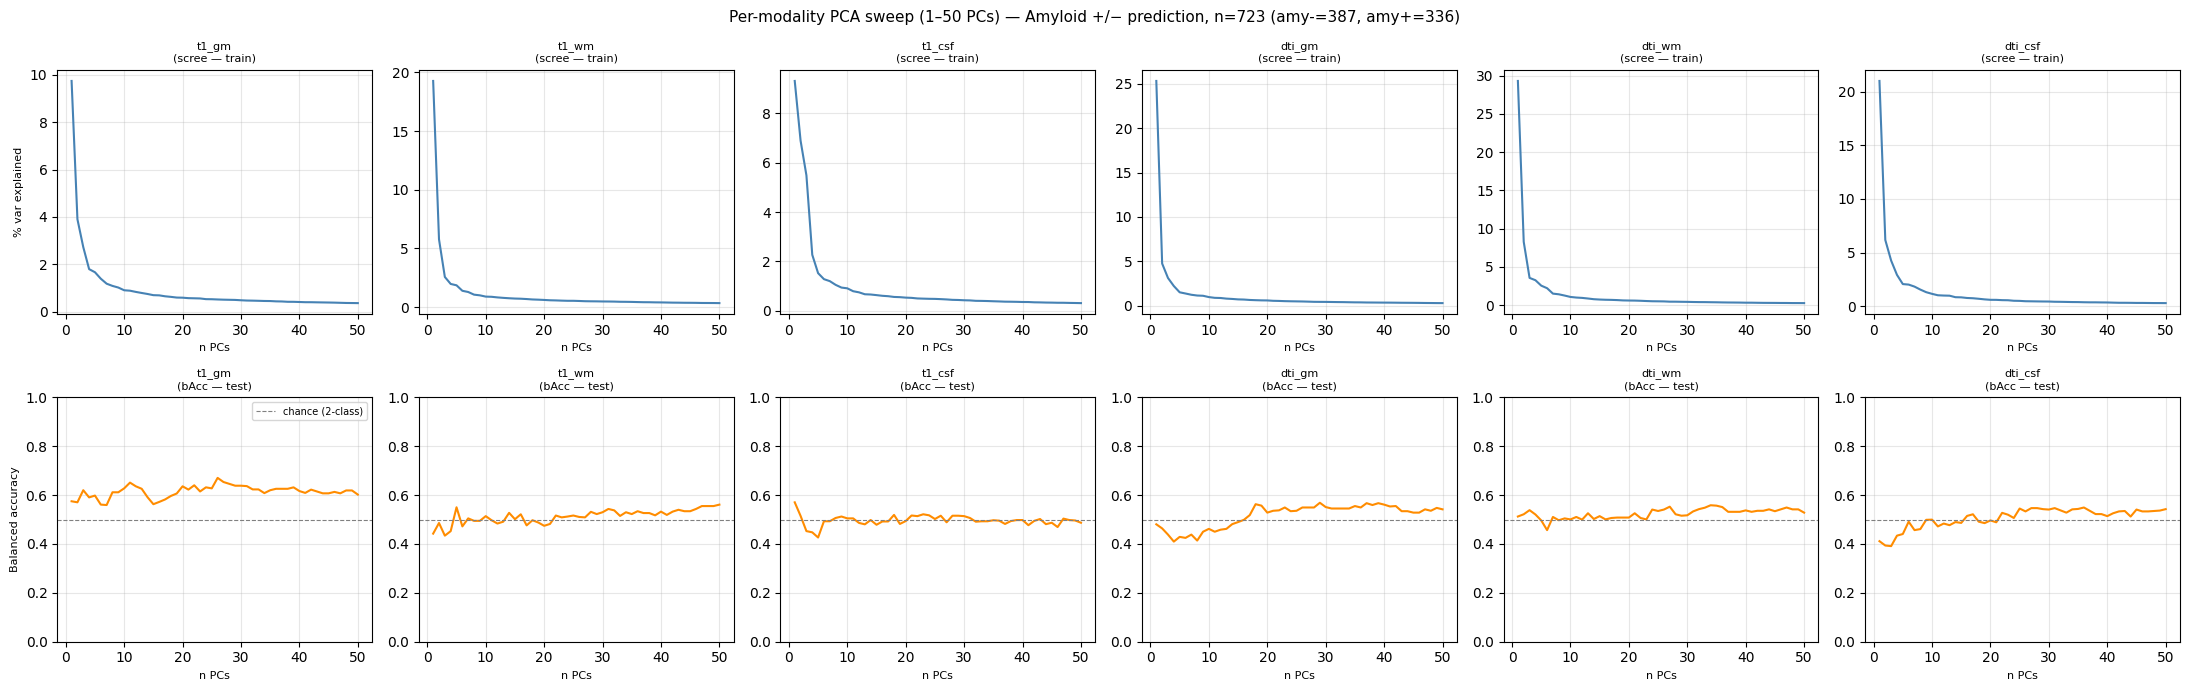

In [9]:
# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 6, figsize=(22, 7))

for col, mod in enumerate(MODALITIES):
    sub_s = amy_scree_df[amy_scree_df["modality"] == mod]
    sub_b = amy_bacc_df[amy_bacc_df["modality"]  == mod]

    ax_s = axes[0, col]
    ax_s.plot(sub_s["n_pc"], sub_s["var_explained"] * 100, color="steelblue", lw=1.5)
    ax_s.set_title(f"{mod}\n(scree — train)", fontsize=8)
    ax_s.set_xlabel("n PCs", fontsize=8)
    ax_s.set_ylabel("% var explained" if col == 0 else "", fontsize=8)
    ax_s.grid(True, alpha=0.3)

    ax_b = axes[1, col]
    ax_b.plot(sub_b["n_pc"], sub_b["bAcc"], color="darkorange", lw=1.5)
    ax_b.axhline(0.5, color="grey", lw=0.8, ls="--", label="chance (2-class)")
    ax_b.set_xlabel("n PCs", fontsize=8)
    ax_b.set_ylabel("Balanced accuracy" if col == 0 else "", fontsize=8)
    ax_b.set_title(f"{mod}\n(bAcc — test)", fontsize=8)
    ax_b.set_ylim(0, 1)
    ax_b.grid(True, alpha=0.3)
    if col == 0:
        ax_b.legend(fontsize=7)

fig.suptitle(
    "Per-modality PCA sweep (1–50 PCs) — Amyloid +/− prediction, "
    f"n={amy_mask.sum()} (amy-={(y_amy==0).sum()}, amy+={(y_amy==1).sum()})",
    fontsize=11,
)
plt.tight_layout()
plt.show()

In [14]:
# --- Amyloid +/- 5-fold CV, all manufacturers, all modalities ----------------
# Requires meta_sc / scalers from cells above
N_PC = 15

# All manufacturers + valid amyloid label
amy_all_mask   = meta_sc["amyloid_label"].notna()
amy_all_idx    = np.where(amy_all_mask.values)[0]
meta_sc_amy_all = meta_sc[amy_all_mask].reset_index(drop=True)

y_amy_all     = meta_sc_amy_all["amyloid_label"].astype(int).values   # 0=amy-, 1=amy+
groups_amy_all = meta_sc_amy_all["subject_id"].values

mfr_counts = meta_sc_amy_all["dti_mfr"].value_counts()
print(f"All-manufacturer amyloid subset: {len(meta_sc_amy_all)} subjects | "
      f"amy-={(y_amy_all==0).sum()}  amy+={(y_amy_all==1).sum()}")
print("DTI manufacturer breakdown:", mfr_counts.to_dict())
print()

amy_all_records = []

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)

for mod in MODALITIES:
    Xs_full    = scalers[mod].transform(X_raw[mod].astype(np.float32))
    Xs_amy_all = Xs_full[amy_all_idx]

    baccs, senss, specs = [], [], []
    for tr, te in sgkf.split(np.arange(len(y_amy_all)), y_amy_all, groups_amy_all):
        pca = PCA(n_components=N_PC, random_state=0,
                  svd_solver="randomized").fit(Xs_amy_all[tr])
        clf = SVC(class_weight="balanced", random_state=0).fit(
                  pca.transform(Xs_amy_all[tr]), y_amy_all[tr])
        y_pred = clf.predict(pca.transform(Xs_amy_all[te]))
        bacc   = balanced_accuracy_score(y_amy_all[te], y_pred)
        tn, fp, fn, tp = confusion_matrix(
                  y_amy_all[te], y_pred, labels=[0, 1]).ravel()
        baccs.append(bacc)
        senss.append(tp / (tp + fn) if (tp + fn) else float("nan"))
        specs.append(tn / (tn + fp) if (tn + fp) else float("nan"))

    amy_all_records.append({
        "modality":   mod,
        "bAcc_mean":  float(np.mean(baccs)),
        "bAcc_std":   float(np.std(baccs)),
        "sens_mean":  float(np.nanmean(senss)),
        "spec_mean":  float(np.nanmean(specs)),
        "n_test_min": int(min((y_amy_all[te] == 1).sum()
                              for _, te in sgkf.split(
                                  np.arange(len(y_amy_all)),
                                  y_amy_all, groups_amy_all))),
    })
    print(f"  {mod} done")

amy_all_df = pd.DataFrame(amy_all_records)


All-manufacturer amyloid subset: 723 subjects | amy-=387  amy+=336
DTI manufacturer breakdown: {'Siemens': 617, 'GE': 59, 'Philips': 47}

  t1_gm done
  t1_wm done
  t1_csf done
  dti_gm done
  dti_wm done
  dti_csf done


In [15]:
# --- Display amyloid +/- 5-fold CV results (all manufacturers) ---------------
print(f"Amyloid +/- classification — all manufacturers, N_PC={N_PC}, 5-fold CV")
print(f"n={len(meta_sc_amy_all)}  amy-={(y_amy_all==0).sum()}  amy+={(y_amy_all==1).sum()}")
print()

header = (f"{'Modality':<14}  {'bAcc':>6}  {chr(177):>5}  "
          f"{'Sens+':>6}  {'Spec-':>6}  {'n_min':>5}")
print(header)
print("-" * len(header))

for _, row in amy_all_df.iterrows():
    print(f"{row['modality']:<14}  "
          f"{row['bAcc_mean']:>6.3f}  {row['bAcc_std']:>5.3f}  "
          f"{row['sens_mean']:>6.3f}  {row['spec_mean']:>6.3f}  "
          f"{row['n_test_min']:>5}")


Amyloid +/- classification — all manufacturers, N_PC=15, 5-fold CV
n=723  amy-=387  amy+=336

Modality          bAcc      ±   Sens+   Spec-  n_min
----------------------------------------------------
t1_gm            0.553  0.073   0.615   0.491     57
t1_wm            0.518  0.017   0.507   0.529     57
t1_csf           0.501  0.050   0.524   0.479     57
dti_gm           0.540  0.032   0.628   0.453     57
dti_wm           0.525  0.026   0.498   0.553     57
dti_csf          0.497  0.035   0.553   0.440     57


In [26]:
# --- Two-stage parallel pipeline: CN vs Dementia + Amyloid +/-, Siemens only ---
N_PC        = 15
FUSION_MODS = ["t1_gm", "t1_wm", "t1_csf", "dti_gm", "dti_wm", "dti_csf"]
sgkf        = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)

# ── Stage 1: CN vs Dementia (Siemens) ────────────────────────────────────────
stage1_mask = meta_sc_s["group"].isin(["CN", "Dementia"])
meta_s1     = meta_sc_s[stage1_mask].reset_index(drop=True)
s1_local    = np.where(stage1_mask.values)[0]        # indices into meta_sc_s

y_s1   = meta_s1["group"].map({"CN": 0, "Dementia": 1}).values.astype(np.int64)
grp_s1 = meta_s1["subject_id"].values

Xs_s1 = {
    mod: scalers[mod].transform(X_raw[mod].astype(np.float32))[siemens_idx][s1_local]
    for mod in FUSION_MODS
}

s1_baccs, s1_senss, s1_specs = [], [], []
s1_preds = np.full(len(y_s1), -1, dtype=int)

for tr, te in sgkf.split(np.arange(len(y_s1)), y_s1, grp_s1):
    scores = np.zeros(len(te))
    for mod in FUSION_MODS:
        pca = PCA(n_components=N_PC, random_state=0,
                  svd_solver="randomized").fit(Xs_s1[mod][tr])
        clf = SVC(class_weight="balanced", random_state=0).fit(
                  pca.transform(Xs_s1[mod][tr]), y_s1[tr])
        scores += clf.decision_function(pca.transform(Xs_s1[mod][te]))
    y_pred = (scores > 0).astype(int)
    s1_preds[te] = y_pred
    tn, fp, fn, tp = confusion_matrix(y_s1[te], y_pred, labels=[0, 1]).ravel()
    s1_baccs.append(balanced_accuracy_score(y_s1[te], y_pred))
    s1_senss.append(tp / (tp + fn) if (tp + fn) else np.nan)
    s1_specs.append(tn / (tn + fp) if (tn + fp) else np.nan)

print("Stage 1 — CN vs Dementia  (Siemens, score fusion, 6 mods)")
print(f"  bAcc:        {np.mean(s1_baccs):.3f} ± {np.std(s1_baccs):.3f}")
print(f"  Sensitivity: {np.nanmean(s1_senss):.3f}  (Dementia detected)")
print(f"  Specificity: {np.nanmean(s1_specs):.3f}  (CN correctly rejected)")
print(f"  n = {len(y_s1)}  CN={(y_s1==0).sum()}  Dementia={(y_s1==1).sum()}")
print()

Stage 1 — CN vs Dementia  (Siemens, score fusion, 6 mods)
  bAcc:        0.777 ± 0.048
  Sensitivity: 0.655  (Dementia detected)
  Specificity: 0.899  (CN correctly rejected)
  n = 435  CN=363  Dementia=72



In [27]:
# ── Stage 2: Amyloid +/- (Siemens) ──────────────────────────────────────────
amy_s_mask = (meta_sc["dti_mfr"] == "Siemens") & meta_sc["amyloid_label"].notna()
amy_s_idx  = np.where(amy_s_mask.values)[0]
meta_s2    = meta_sc[amy_s_mask].reset_index(drop=True)

y_s2   = meta_s2["amyloid_label"].astype(int).values
grp_s2 = meta_s2["subject_id"].values

Xs_s2 = {
    mod: scalers[mod].transform(X_raw[mod].astype(np.float32))[amy_s_idx]
    for mod in FUSION_MODS
}

s2_baccs, s2_senss, s2_specs = [], [], []
s2_preds = np.full(len(y_s2), -1, dtype=int)

for tr, te in sgkf.split(np.arange(len(y_s2)), y_s2, grp_s2):
    scores = np.zeros(len(te))
    for mod in FUSION_MODS:
        pca = PCA(n_components=N_PC, random_state=0,
                  svd_solver="randomized").fit(Xs_s2[mod][tr])
        clf = SVC(class_weight="balanced", random_state=0).fit(
                  pca.transform(Xs_s2[mod][tr]), y_s2[tr])
        scores += clf.decision_function(pca.transform(Xs_s2[mod][te]))
    y_pred = (scores > 0).astype(int)
    s2_preds[te] = y_pred
    tn, fp, fn, tp = confusion_matrix(y_s2[te], y_pred, labels=[0, 1]).ravel()
    s2_baccs.append(balanced_accuracy_score(y_s2[te], y_pred))
    s2_senss.append(tp / (tp + fn) if (tp + fn) else np.nan)
    s2_specs.append(tn / (tn + fp) if (tn + fp) else np.nan)

print("Stage 2 — Amyloid +/-  (Siemens, score fusion, 6 mods)")
print(f"  bAcc:        {np.mean(s2_baccs):.3f} ± {np.std(s2_baccs):.3f}")
print(f"  Sensitivity: {np.nanmean(s2_senss):.3f}  (Amy+ detected)")
print(f"  Specificity: {np.nanmean(s2_specs):.3f}  (Amy− correctly rejected)")
print(f"  n = {len(y_s2)}  Amy−={(y_s2==0).sum()}  Amy+={(y_s2==1).sum()}")
print()

Stage 2 — Amyloid +/-  (Siemens, score fusion, 6 mods)
  bAcc:        0.553 ± 0.039
  Sensitivity: 0.657  (Amy+ detected)
  Specificity: 0.448  (Amy− correctly rejected)
  n = 617  Amy−=334  Amy+=283



In [28]:
# ── Joint evaluation: subjects with both CN/Dem label AND amyloid label ──────
# Use original row index in meta_sc as join key (handles repeated subject_ids safely)
siemens_sc_positions = np.where(
    (meta_sc["dti_mfr"] == "Siemens") & meta_sc["group"].notna()
)[0]
s1_orig_idx = siemens_sc_positions[s1_local]   # row in meta_sc for each Stage-1 subject

s1_df = meta_s1[["subject_id", "group"]].copy()
s1_df["_orig"]   = s1_orig_idx
s1_df["s1_true"] = y_s1
s1_df["s1_pred"] = s1_preds

s2_df = meta_s2[["subject_id", "amyloid_label"]].copy()
s2_df["_orig"]   = amy_s_idx
s2_df["s2_true"] = y_s2
s2_df["s2_pred"] = s2_preds

joint = s1_df.merge(s2_df[["_orig", "s2_true", "s2_pred"]], on="_orig", how="inner")

print(f"Joint evaluation: {len(joint)} scan-pairs with both labels (Siemens)")
joint["diag_true_lbl"] = joint["s1_true"].map({0: "CN",  1: "Dem"})
joint["diag_pred_lbl"] = joint["s1_pred"].map({0: "CN",  1: "Dem"})
joint["amy_true_lbl"]  = joint["s2_true"].map({0: "Amy−", 1: "Amy+"})
joint["amy_pred_lbl"]  = joint["s2_pred"].map({0: "Amy−", 1: "Amy+"})
joint["true_combo"]    = joint["diag_true_lbl"] + " / " + joint["amy_true_lbl"]
joint["pred_combo"]    = joint["diag_pred_lbl"] + " / " + joint["amy_pred_lbl"]

cross = pd.crosstab(joint["true_combo"], joint["pred_combo"],
                    rownames=["True"], colnames=["Predicted"])
# ensure all 4 columns present
for col in ["CN / Amy−", "CN / Amy+", "Dem / Amy−", "Dem / Amy+"]:
    if col not in cross.columns:
        cross[col] = 0
cross = cross[["CN / Amy−", "CN / Amy+", "Dem / Amy−", "Dem / Amy+"]]
print("\n4-way cross-tabulation (True × Predicted):")
print(cross.to_string())
print()

both_correct = (joint["s1_true"] == joint["s1_pred"]) & (joint["s2_true"] == joint["s2_pred"])
s1_on_joint  = (joint["s1_true"] == joint["s1_pred"]).mean()
s2_on_joint  = (joint["s2_true"] == joint["s2_pred"]).mean()
print(f"Both correct:              {both_correct.mean():.3f}  ({both_correct.sum()}/{len(joint)})")
print(f"Stage 1 correct on joint:  {s1_on_joint:.3f}")
print(f"Stage 2 correct on joint:  {s2_on_joint:.3f}")
print()
print("Amy+ rate by predicted diagnosis class (clinical plausibility check):")
for dx_str, dx_true in [("CN", 0), ("Dementia", 1)]:
    sub = joint[joint["s1_true"] == dx_true]
    if len(sub):
        amy_pos_rate = (sub["s2_pred"] == 1).mean()
        print(f"  True {dx_str:8s}: predicted Amy+ in {amy_pos_rate:.1%}  (n={len(sub)})")


Joint evaluation: 396 scan-pairs with both labels (Siemens)

4-way cross-tabulation (True × Predicted):
Predicted   CN / Amy−  CN / Amy+  Dem / Amy−  Dem / Amy+
True                                                    
CN / Amy+          65         57           5          13
CN / Amy−         101         70           1          19
Dem / Amy+          2         12          11          21
Dem / Amy−          3          4           2          10

Both correct:              0.457  (181/396)
Stage 1 correct on joint:  0.851
Stage 2 correct on joint:  0.530

Amy+ rate by predicted diagnosis class (clinical plausibility check):
  True CN      : predicted Amy+ in 48.0%  (n=331)
  True Dementia: predicted Amy+ in 72.3%  (n=65)


In [29]:
print("Actual Amy+ prevalence by true diagnosis:")
for dx_str, dx_true in [("CN", 0), ("Dementia", 1)]:
    sub = joint[joint["s1_true"] == dx_true]
    actual = (sub["s2_true"] == 1).mean()
    predicted = (sub["s2_pred"] == 1).mean()
    print(f"  True {dx_str:8s}: actual Amy+ = {actual:.1%}, predicted Amy+ = {predicted:.1%}  (n={len(sub)})")

Actual Amy+ prevalence by true diagnosis:
  True CN      : actual Amy+ = 42.3%, predicted Amy+ = 48.0%  (n=331)
  True Dementia: actual Amy+ = 70.8%, predicted Amy+ = 72.3%  (n=65)


In [18]:
# --- OvA setup: joint mask (valid group + amyloid label) ---------------------
joint_mask  = meta["group"].notna() & meta["amyloid_label"].notna()
meta_joint  = meta[joint_mask].reset_index(drop=True)
joint_idx   = np.where(joint_mask.values)[0]
groups_ova  = meta_joint["subject_id"].values

ova_tasks = {
    "CN / Amy+":  (meta_joint["group"].eq("CN"))       & (meta_joint["amyloid_label"] == 1.0),
    "CN / Amy−":  (meta_joint["group"].eq("CN"))       & (meta_joint["amyloid_label"] == 0.0),
    "Dem / Amy+": (meta_joint["group"].eq("Dementia")) & (meta_joint["amyloid_label"] == 1.0),
    "Dem / Amy−": (meta_joint["group"].eq("Dementia")) & (meta_joint["amyloid_label"] == 0.0),
}

print(f"Joint subset: {len(meta_joint)} subjects")
for name, pos_mask in ova_tasks.items():
    print(f"  {name:<14}: pos={pos_mask.sum():>3}  neg={(~pos_mask).sum():>3}")

Joint subset: 711 subjects
  CN / Amy+     : pos=157  neg=554
  CN / Amy−     : pos=222  neg=489
  Dem / Amy+    : pos= 50  neg=661
  Dem / Amy−    : pos= 20  neg=691



CN / Amy+  (pos=157, neg=554, ratio=3.5:1)
  Modality               AUC        bAcc         Acc
  ──────────────  ──────────  ──────────  ──────────
  t1_gm           0.631±0.062  0.600±0.042  0.566±0.033
  t1_wm           0.603±0.086  0.582±0.064  0.565±0.042
  t1_csf          0.603±0.080  0.570±0.070  0.553±0.083
  dti_gm          0.595±0.040  0.543±0.027  0.519±0.053
  dti_wm          0.625±0.024  0.588±0.055  0.529±0.061
  dti_csf         0.541±0.057  0.534±0.044  0.568±0.033

CN / Amy−  (pos=222, neg=489, ratio=2.2:1)
  Modality               AUC        bAcc         Acc
  ──────────────  ──────────  ──────────  ──────────
  t1_gm           0.678±0.035  0.643±0.050  0.599±0.054
  t1_wm           0.617±0.077  0.602±0.056  0.565±0.043
  t1_csf          0.625±0.024  0.587±0.018  0.573±0.028
  dti_gm          0.646±0.036  0.598±0.042  0.581±0.064
  dti_wm          0.637±0.050  0.561±0.058  0.552±0.071
  dti_csf         0.623±0.017  0.578±0.021  0.574±0.045

Dem / Amy+  (pos=50, neg=66

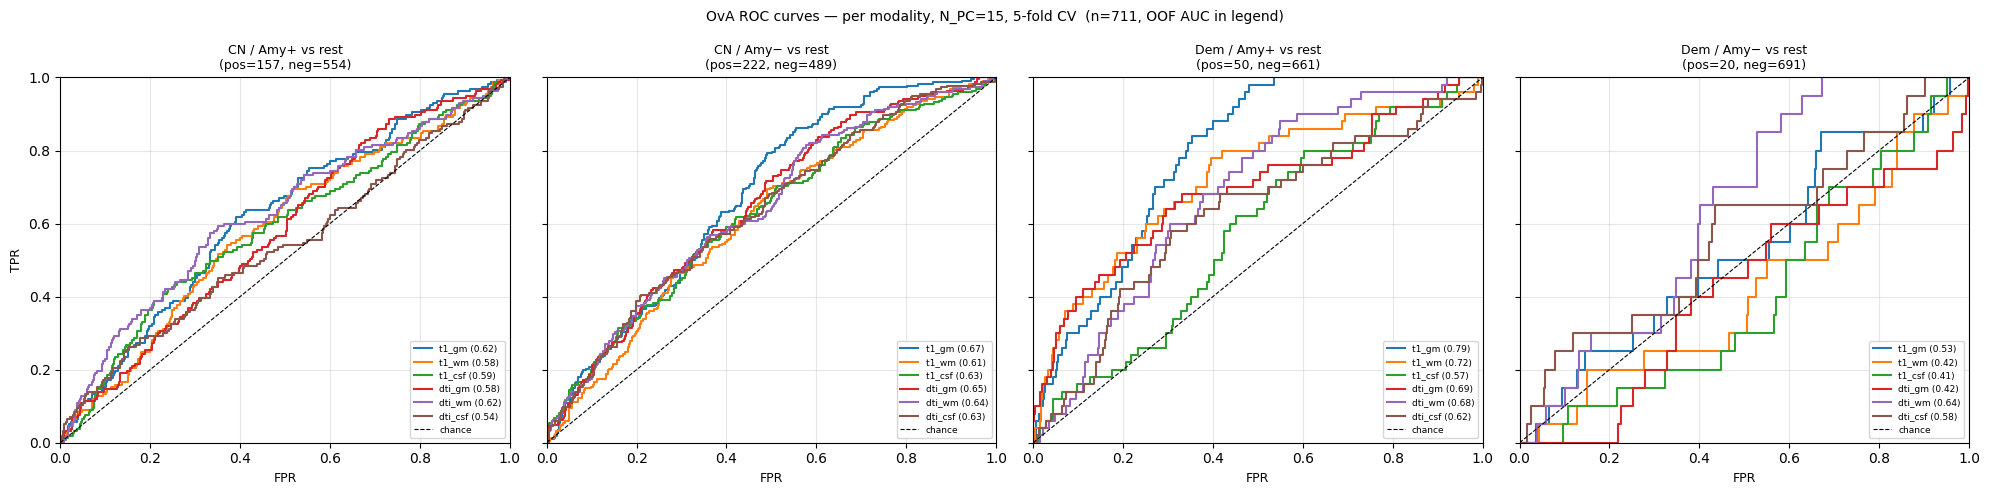

In [12]:
# --- OvA ROC-AUC: CN/Amy+, CN/Amy−, Dem/Amy+, Dem/Amy− vs rest -------------
# OOF decision scores → one smooth ROC curve per (task, modality).
# Printed table: fold mean ± std for AUC, balanced accuracy, and plain accuracy.
from sklearn.metrics import accuracy_score

N_PC = 15
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)

MOD_COLORS = dict(zip(MODALITIES,
    ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]))

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

for ax, (task_name, pos_mask) in zip(axes, ova_tasks.items()):
    y_ova = pos_mask.astype(np.int64).values
    n_pos = int(y_ova.sum())
    n_neg = len(y_ova) - n_pos

    print(f"\n{task_name}  (pos={n_pos}, neg={n_neg}, ratio={n_neg/n_pos:.1f}:1)")
    print(f"  {'Modality':<14}  {'AUC':>10}  {'bAcc':>10}  {'Acc':>10}")
    print(f"  {'─'*14}  {'─'*10}  {'─'*10}  {'─'*10}")

    for mod in MODALITIES:
        Xs_full    = scalers[mod].transform(X_raw[mod].astype(np.float32))
        Xs_ova     = Xs_full[joint_idx]

        oof_scores = np.zeros(len(y_ova))
        fold_aucs, fold_baccs, fold_accs = [], [], []

        for tr, te in sgkf.split(np.arange(len(y_ova)), y_ova, groups_ova):
            pca = PCA(n_components=N_PC, random_state=0,
                      svd_solver="randomized").fit(Xs_ova[tr])
            clf = SVC(class_weight="balanced", random_state=0).fit(
                      pca.transform(Xs_ova[tr]), y_ova[tr])
            s      = clf.decision_function(pca.transform(Xs_ova[te]))
            y_pred = clf.predict(pca.transform(Xs_ova[te]))
            oof_scores[te] = s
            fpr_f, tpr_f, _ = roc_curve(y_ova[te], s)
            fold_aucs.append(auc(fpr_f, tpr_f))
            fold_baccs.append(balanced_accuracy_score(y_ova[te], y_pred))
            fold_accs.append(accuracy_score(y_ova[te], y_pred))

        fpr, tpr, _ = roc_curve(y_ova, oof_scores)
        oof_auc = auc(fpr, tpr)

        ax.plot(fpr, tpr, color=MOD_COLORS[mod], lw=1.5,
                label=f"{mod} ({oof_auc:.2f})")

        print(f"  {mod:<14}  "
              f"{np.mean(fold_aucs):>5.3f}±{np.std(fold_aucs):.3f}  "
              f"{np.mean(fold_baccs):>5.3f}±{np.std(fold_baccs):.3f}  "
              f"{np.mean(fold_accs):>5.3f}±{np.std(fold_accs):.3f}")

    ax.plot([0, 1], [0, 1], "k--", lw=0.8, label="chance")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel("FPR", fontsize=9)
    ax.set_title(f"{task_name} vs rest\n(pos={n_pos}, neg={n_neg})", fontsize=9)
    ax.legend(fontsize=6.5, loc="lower right")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("TPR", fontsize=9)
fig.suptitle(
    f"OvA ROC curves — per modality, N_PC={N_PC}, 5-fold CV  "
    f"(n={len(meta_joint)}, OOF AUC in legend)",
    fontsize=10,
)
plt.tight_layout()
plt.show()

In [30]:
from sklearn.svm import LinearSVC

N_PC = 15
weight_maps = {mod: [] for mod in FUSION_MODS}   # per-fold weights in voxel space
activation_maps = {mod: [] for mod in FUSION_MODS}

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)

for tr, te in sgkf.split(np.arange(len(y_s1)), y_s1, grp_s1):
    for mod in FUSION_MODS:
        Xs = Xs_s1[mod]
        pca = PCA(n_components=N_PC, random_state=0, svd_solver="randomized").fit(Xs[tr])
        X_pc_tr = pca.transform(Xs[tr])

        clf = LinearSVC(class_weight="balanced", max_iter=5000, random_state=0)
        clf.fit(X_pc_tr, y_s1[tr])

        # Back-project weight vector to voxel space
        w_pc = clf.coef_[0]                        # (n_PCs,)
        w_vox = pca.components_.T @ w_pc           # (n_voxels,)

        # Haufe activation pattern
        sigma_x = np.cov(X_pc_tr.T)               # (n_PCs × n_PCs)
        a_pc = sigma_x @ w_pc / (w_pc @ sigma_x @ w_pc)
        a_vox = pca.components_.T @ a_pc           # (n_voxels,)

        weight_maps[mod].append(w_vox)
        activation_maps[mod].append(a_vox)

# Average across folds
mean_weights = {mod: np.mean(weight_maps[mod], axis=0) for mod in FUSION_MODS}
mean_acts    = {mod: np.mean(activation_maps[mod], axis=0) for mod in FUSION_MODS}
std_acts     = {mod: np.std(activation_maps[mod], axis=0) for mod in FUSION_MODS}

In [15]:
ref_path = next(Path("model_data/adni/t1_long_data/t1_long_modulated_vbm/t1_long_pve_smoothed")
                .glob("*/*_pve_1_mod_s2p5.nii.gz"))
ref_img = nib.load(str(ref_path))

def _load_mask(path):
    m = nli.resample_to_img(str(path), ref_img,
                            interpolation="nearest",
                            force_resample=True, copy_header=True)
    return np.asarray(m.dataobj) > 0.5

gm_mask  = _load_mask("model_data/mni_gm_mask_fast.nii")
wm_mask  = _load_mask("model_data/mni_wm_mask_fast.nii")
csf_mask = _load_mask("model_data/mni_csf_mask_fast.nii")

In [36]:
# Step 2: map activation vector → 3D NIfTI
mask_for = {"t1_gm": gm_mask, "t1_wm": wm_mask, "t1_csf": csf_mask,
            "dti_gm": gm_mask, "dti_wm": wm_mask, "dti_csf": csf_mask}

Path("model_data/brain_maps").mkdir(exist_ok=True)

for mod, act_vec in mean_acts.items():         # mean_acts from the LinearSVC cell
    mask = mask_for[mod]
    vol  = np.zeros(mask.shape, dtype=np.float32)
    vol[mask] = act_vec
    img = nib.Nifti1Image(vol, ref_img.affine, ref_img.header)
    nib.save(img, f"model_data/brain_maps/act_{mod}_CN_vs_Dem.nii.gz")
    print(f"Saved {mod}: {vol.shape}, {mask.sum():,} voxels filled")

Saved t1_gm: (182, 218, 182), 831,863 voxels filled
Saved t1_wm: (182, 218, 182), 785,285 voxels filled
Saved t1_csf: (182, 218, 182), 337,620 voxels filled
Saved dti_gm: (182, 218, 182), 831,863 voxels filled
Saved dti_wm: (182, 218, 182), 785,285 voxels filled
Saved dti_csf: (182, 218, 182), 337,620 voxels filled


In [49]:
mask_for = {"t1_gm": gm_mask, "t1_wm": wm_mask, "t1_csf": csf_mask,
            "dti_gm": gm_mask, "dti_wm": wm_mask, "dti_csf": csf_mask}

# ── Build NIfTI volumes for weight maps and z-scored activation maps ─────────
for mod in FUSION_MODS:
    mask = mask_for[mod]

    # Raw weight back-projection (sharper, good for figures)
    w_vol = np.zeros(mask.shape, dtype=np.float32)
    w_vol[mask] = mean_weights[mod]
    nib.save(nib.Nifti1Image(w_vol, ref_img.affine),
             f"model_data/brain_maps/weight_{mod}_CN_vs_Dem.nii.gz")

    # Cross-fold z-score of activation pattern (consistency across folds)
    # z > 1.96: signal present in >95% of folds; z < 1: unstable
    z = mean_acts[mod] / (std_acts[mod] + 1e-10)
    z_vol = np.zeros(mask.shape, dtype=np.float32)
    z_vol[mask] = z
    nib.save(nib.Nifti1Image(z_vol, ref_img.affine),
             f"model_data/brain_maps/zact_{mod}_CN_vs_Dem.nii.gz")

Value ranges (weight maps):
  t1_gm       95th%=0.00002  99.5th%=0.00003
  t1_wm       95th%=0.00001  99.5th%=0.00002
  t1_csf      95th%=0.00003  99.5th%=0.00004
  dti_gm      95th%=0.00002  99.5th%=0.00003
  dti_wm      95th%=0.00002  99.5th%=0.00004
  dti_csf     95th%=0.00002  99.5th%=0.00003



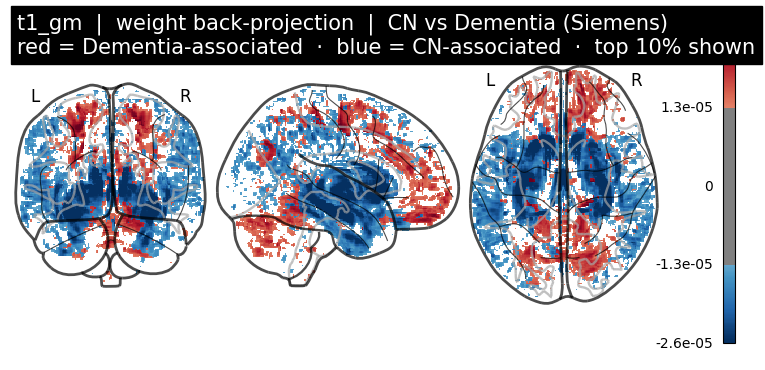

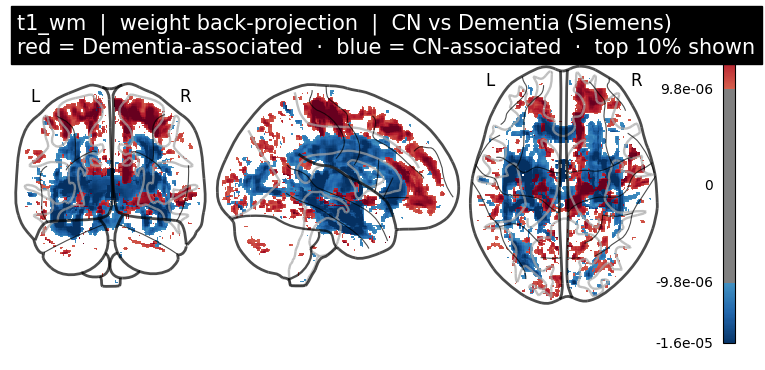

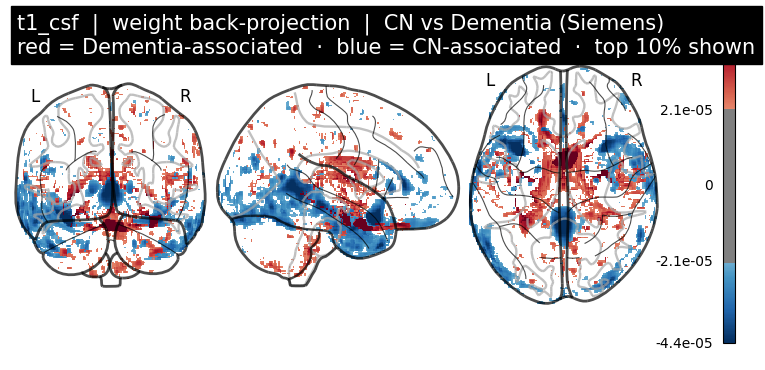

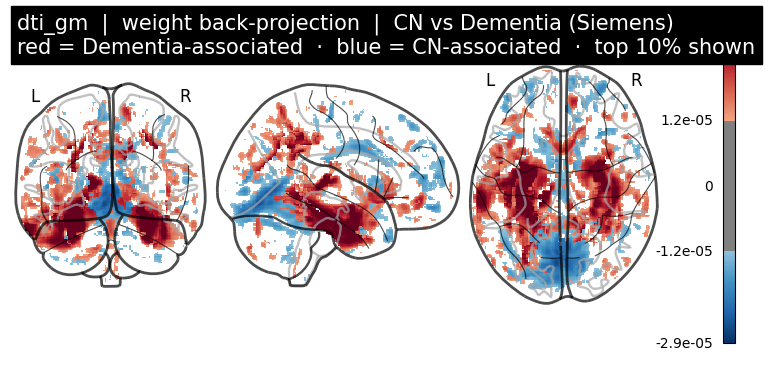

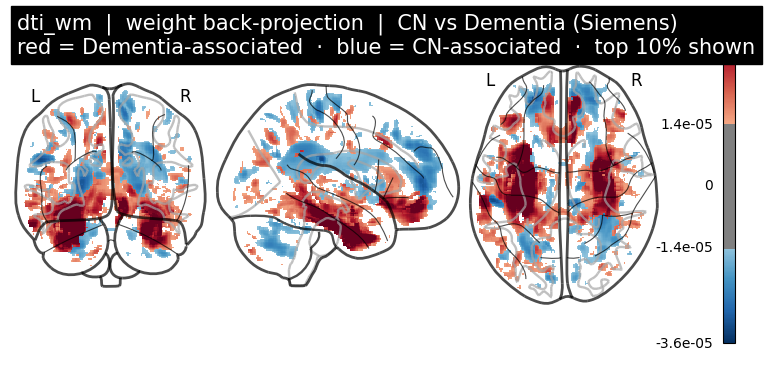

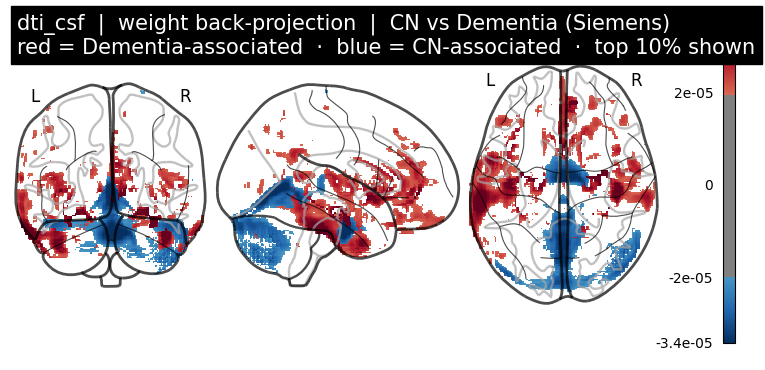

In [16]:
# ── Per-modality brain maps: weight back-projection ──────────────────────────
# red = Dementia-associated (positive weight: higher signal here → predicts Dementia)
# blue = CN-associated (negative weight: higher signal here → predicts CN)
# Only top 10% of absolute weights shown (90th percentile threshold).

FUSION_MODS = ["t1_gm", "t1_wm", "t1_csf", "dti_gm", "dti_wm", "dti_csf"]
mask_for = {"t1_gm": gm_mask, "t1_wm": wm_mask, "t1_csf": csf_mask,
            "dti_gm": gm_mask, "dti_wm": wm_mask, "dti_csf": csf_mask}

print("Value ranges (weight maps):")
for mod in FUSION_MODS:
    img  = nib.load(f"model_data/brain_maps/weight_{mod}_CN_vs_Dem.nii.gz")
    data = img.get_fdata()
    nz   = np.abs(data[data != 0])
    print(f"  {mod:<10}  95th%={np.percentile(nz,95):.5f}  "
          f"99.5th%={np.percentile(nz,99.5):.5f}")
print()

for mod in FUSION_MODS:
    img  = nib.load(f"model_data/brain_maps/weight_{mod}_CN_vs_Dem.nii.gz")
    data = img.get_fdata()
    nz   = np.abs(data[data != 0])
    thr  = float(np.percentile(nz, 90))
    vmax = float(np.percentile(nz, 99.5))

    nlp.plot_glass_brain(
        img,
        colorbar=True,
        plot_abs=False,
        threshold=thr,
        vmax=vmax,
        title=f"{mod}  |  weight back-projection  |  CN vs Dementia (Siemens)\n"
              f"red = Dementia-associated  ·  blue = CN-associated  ·  top 10% shown",
        cmap="RdBu_r",
    )
    plt.savefig(f"model_data/brain_maps/weight_{mod}_CN_vs_Dem.png",
                dpi=150, bbox_inches="tight")
    plt.show()

Value ranges (z-scored activation maps):
  t1_gm       95th%=12.01  max=198.12  voxels with |z|>1.96: 623,636
  t1_wm       95th%=7.19  max=116.50  voxels with |z|>1.96: 461,418
  t1_csf      95th%=3.66  max=54.56  voxels with |z|>1.96: 167,002
  dti_gm      95th%=5.50  max=29.98  voxels with |z|>1.96: 618,094
  dti_wm      95th%=7.69  max=144.43  voxels with |z|>1.96: 544,916
  dti_csf     95th%=13.39  max=152.13  voxels with |z|>1.96: 284,870



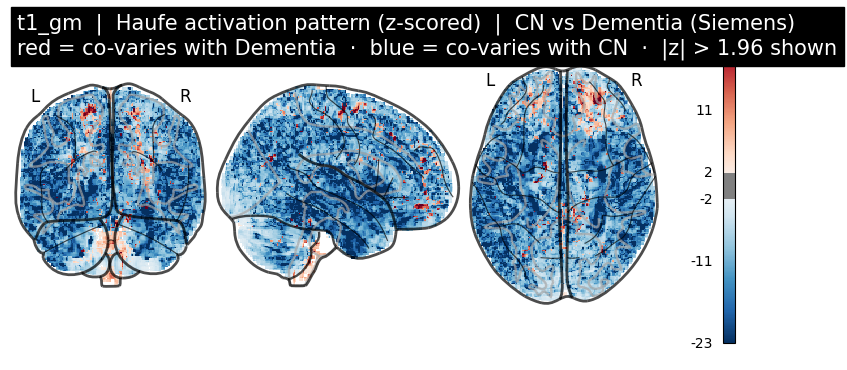

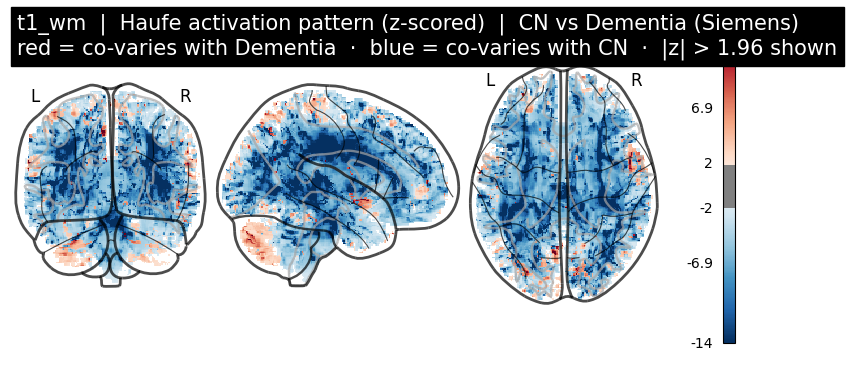

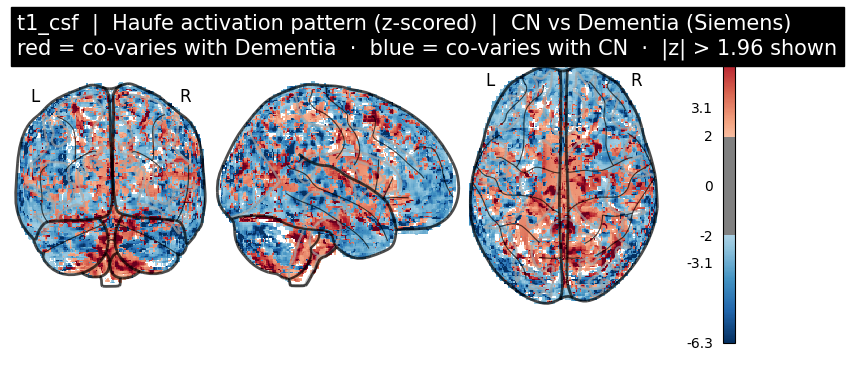

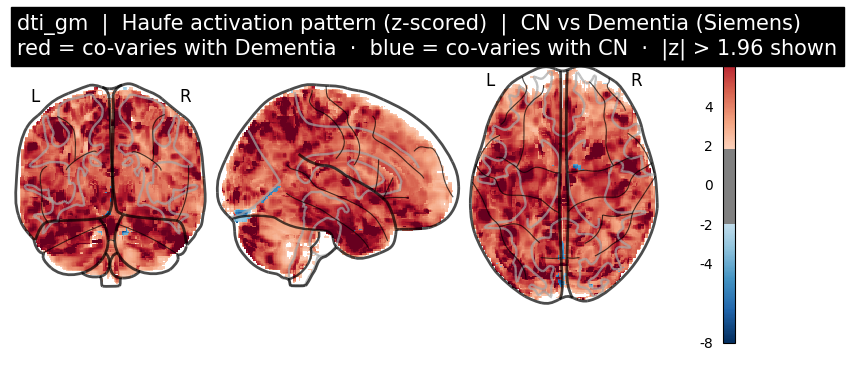

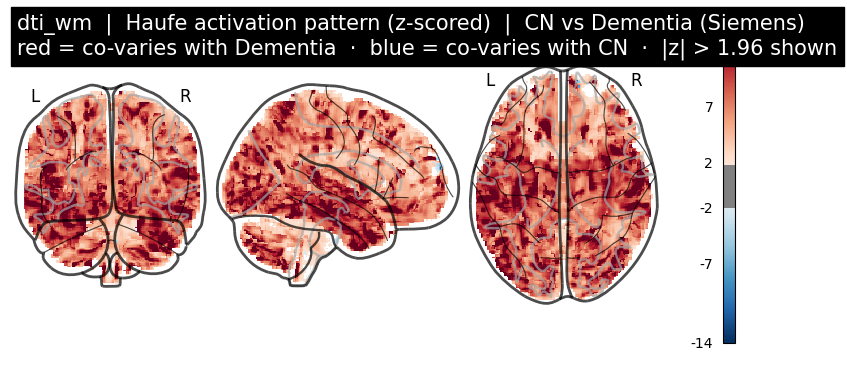

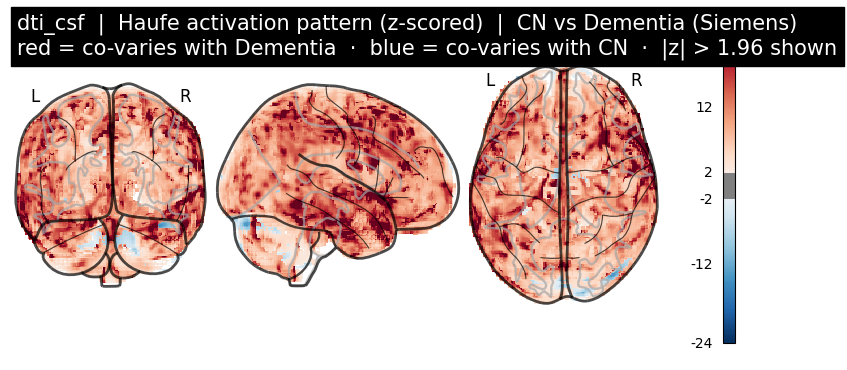

In [17]:
# ── Haufe activation patterns (z-scored across folds) ────────────────────────
# Threshold: z > 1.96 — voxels whose activation was consistent across all 5 folds.
# red = co-varies with Dementia prediction  ·  blue = co-varies with CN prediction

print("Value ranges (z-scored activation maps):")
for mod in FUSION_MODS:
    img  = nib.load(f"model_data/brain_maps/zact_{mod}_CN_vs_Dem.nii.gz")
    data = img.get_fdata()
    nz   = np.abs(data[data != 0])
    print(f"  {mod:<10}  95th%={np.percentile(nz,95):.2f}  "
          f"max={nz.max():.2f}  "
          f"voxels with |z|>1.96: {(nz > 1.96).sum():,}")
print()

Z_THR = 1.96   # ~95% fold-consistency

for mod in FUSION_MODS:
    img  = nib.load(f"model_data/brain_maps/zact_{mod}_CN_vs_Dem.nii.gz")
    data = img.get_fdata()
    nz   = np.abs(data[data != 0])
    vmax = float(np.percentile(nz, 99.5))

    nlp.plot_glass_brain(
        img,
        colorbar=True,
        plot_abs=False,
        threshold=Z_THR,
        vmax=vmax,
        title=f"{mod}  |  Haufe activation pattern (z-scored)  |  CN vs Dementia (Siemens)\n"
              f"red = co-varies with Dementia  ·  blue = co-varies with CN  ·  |z| > 1.96 shown",
        cmap="RdBu_r",
    )
    plt.savefig(f"model_data/brain_maps/zact_{mod}_CN_vs_Dem.png",
                dpi=150, bbox_inches="tight")
    plt.show()

## Demographic covariates: age at scan & sex

ADNI's processed CSVs (`paired_df_long_v2.csv`, `DXSUM`, amyloid file) carry no age/sex columns, but the raw T1 DICOM headers do (`PatientAge`, `PatientSex`). Extraction is imperfect: a subset of scans (mostly certain Siemens sites) have a corrupted `PatientSex == "O"` or a garbled `PatientAge` (wrong units/format). We extract what's clean and **drop** rows where either field is missing/invalid, rather than imputing — this keeps the demographic-augmented analysis honest at the cost of some sample size. `meta` itself is left untouched (just gains two nullable columns) so every other analysis in this notebook is unaffected.

In [6]:
# ── Extract age-at-scan & sex from T1 DICOM headers ──────────────────────────
import re

_dcm_root = DATA / "t1_long_data" / "t1_long_dcm"
_img_ids  = set(meta["t1_image_id"].astype(str))

_img_to_file = {}
for _subj_dir in _dcm_root.iterdir():
    if not _subj_dir.is_dir(): continue
    for _series_dir in _subj_dir.iterdir():
        if not _series_dir.is_dir(): continue
        for _date_dir in _series_dir.iterdir():
            if not _date_dir.is_dir(): continue
            for _id_dir in _date_dir.iterdir():
                if not _id_dir.is_dir(): continue
                _iid = _id_dir.name.lstrip("I")
                if _iid in _img_ids and _iid not in _img_to_file:
                    _files = list(_id_dir.glob("*.dcm"))
                    if _files:
                        _img_to_file[_iid] = _files[0]

_age_pat = re.compile(r"^(\d{3})Y$")

def _extract_age_sex(fp):
    """Return (age_years, sex) from a DICOM header, or (None, None) if missing/invalid."""
    try:
        ds = pydicom.dcmread(str(fp), stop_before_pixels=True, force=True)
        age_raw = str(getattr(ds, "PatientAge", "") or "")
        sex_raw = str(getattr(ds, "PatientSex", "") or "")
        m = _age_pat.match(age_raw)
        age = int(m.group(1)) if m else None
        if age is not None and not (40 <= age <= 100):   # plausible ADNI range
            age = None
        sex = sex_raw if sex_raw in ("M", "F") else None
        return age, sex
    except Exception:
        return None, None

_age_sex = [
    _extract_age_sex(_img_to_file.get(str(_iid))) if str(_iid) in _img_to_file else (None, None)
    for _iid in meta["t1_image_id"]
]
meta["age_at_scan"] = [a for a, s in _age_sex]
meta["sex"]         = [s for a, s in _age_sex]

print(f"age_at_scan: {meta['age_at_scan'].notna().sum()}/{len(meta)} valid")
print(f"sex:         {meta['sex'].notna().sum()}/{len(meta)} valid")

demo_mask = meta["age_at_scan"].notna() & meta["sex"].notna() & meta["group"].notna()
print(f"\nRows with clean age + sex + group: {demo_mask.sum()}/{len(meta)}  "
      f"({meta.loc[demo_mask, 'subject_id'].nunique()} unique subjects)")

age_at_scan: 626/786 valid
sex:         627/786 valid

Rows with clean age + sex + group: 567/786  (391 unique subjects)


Cohort average age at scan: 74.2 yrs (n=567)
          mean  std  count
group                     
CN        72.9  7.8    297
Dementia  75.1  8.9     47
MCI       75.8  8.2    223

group     sex
CN        F      177
          M      120
Dementia  F       24
          M       23
MCI       M      121
          F      102
Name: count, dtype: int64


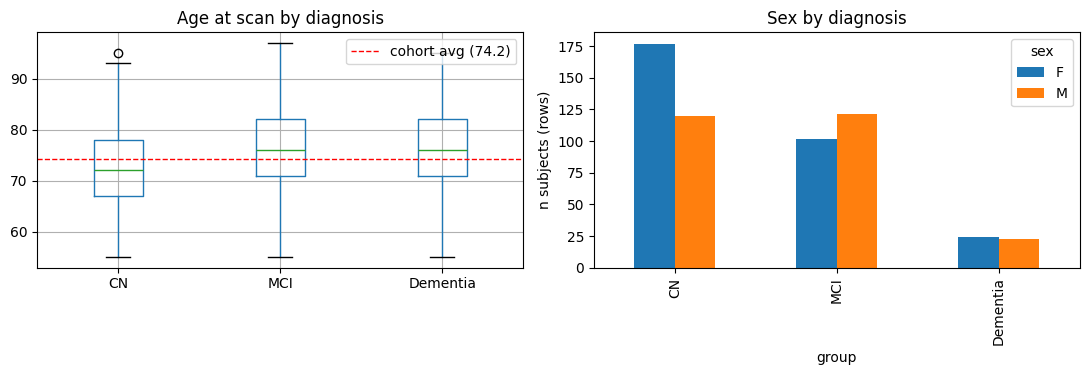

In [7]:
# ── EDA: age at scan vs cohort average, and sex, by diagnostic group ─────────
_demo = meta[demo_mask]
_avg_age = _demo["age_at_scan"].mean()
print(f"Cohort average age at scan: {_avg_age:.1f} yrs (n={len(_demo)})")
print(_demo.groupby("group")["age_at_scan"].agg(["mean", "std", "count"]).round(1))
print()
print(_demo.groupby("group")["sex"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

_order = ["CN", "MCI", "Dementia"]
_demo.boxplot(column="age_at_scan", by="group", ax=axes[0],
              positions=[ _order.index(g) for g in
                          _demo.groupby("group")["age_at_scan"].mean().index ])
axes[0].axhline(_avg_age, color="red", ls="--", lw=1, label=f"cohort avg ({_avg_age:.1f})")
axes[0].set_title("Age at scan by diagnosis")
axes[0].set_xlabel("")
axes[0].legend()
fig.suptitle("")

_ct = _demo.groupby(["group", "sex"]).size().unstack(fill_value=0).reindex(_order)
_ct.plot(kind="bar", ax=axes[1])
axes[1].set_title("Sex by diagnosis")
axes[1].set_ylabel("n subjects (rows)")

plt.tight_layout()
plt.show()

### Age + sex injected post-PCA into the SVM

Restricting to the clean-demographics cohort (`demo_mask`), we repeat the notebook's standard whole-brain-mask PCA + SVC score-fusion pipeline (per-modality `StandardScaler` from `scalers` fit on CN subjects + a single whole-brain `PCA(n_components=15)` per modality, decision functions summed across modalities — same design as the "Multimodal score fusion" cells above) on identical 5-fold splits, four times: **baseline** (imaging PCs only), **+ age**, **+ sex**, and **+ age + sex** — each concatenating the relevant covariate(s) to each modality's 15 PC scores right before that modality's `SVC.fit`, i.e. after PCA, before the SVM. This isolates age's and sex's individual contributions from their combined effect.

**Scale matching:** raw whole-brain PCA scores can have much larger variance than a z-scored age column or a 0/1 sex column (top PCs over thousands of unit-variance voxels routinely have std in the tens), so `SVC`'s RBF kernel will ignore small-scale covariates entirely if they're concatenated at native scale. Each augmented block (PCs + whichever covariate(s) apply) is therefore re-standardized with a fresh `StandardScaler` fit per fold before its `SVC` is trained; the baseline PCA scores are left untouched.

**`DEMO_WEIGHT` knob:** a sweep on the combined age+sex variant found upweighting the covariates beyond their standardized scale hurts (1.0 → bAcc 0.690 best, 1.5 → 0.667, 3.0 → 0.644), so it's left at 1.0 (no extra emphasis) here — change it to re-sweep.

In [8]:
# ── CN vs MCI+Dementia: baseline vs age-only vs sex-only vs age+sex, whole-brain PCA ─────────
N_PC        = 15
DEMO_WEIGHT = 1.0   # sweep (age+sex): 1.0->bAcc 0.690 (best), 1.5->0.667, 3.0->0.644

VARIANTS = {
    "baseline":  [],
    "+ age":     ["age"],
    "+ sex":     ["sex"],
    "+ age+sex": ["age", "sex"],
}

_sub_demo  = meta[demo_mask].reset_index(drop=True)
_idx_demo  = np.where(demo_mask.values)[0]
_y_demo    = _sub_demo["group"].map({"CN": 0, "MCI": 1, "Dementia": 1}).values.astype(np.int64)
_grp_demo  = _sub_demo["subject_id"].values
_age_demo  = _sub_demo["age_at_scan"].values.astype(np.float32)
_sex_demo  = _sub_demo["sex"].map({"M": 0, "F": 1}).values.astype(np.float32)

print(f"Restricted cohort: {len(_y_demo)} rows  "
      f"(CN={_sub_demo['group'].eq('CN').sum()}, "
      f"MCI={_sub_demo['group'].eq('MCI').sum()}, "
      f"Dementia={_sub_demo['group'].eq('Dementia').sum()})")
print(f"DEMO_WEIGHT = {DEMO_WEIGHT}")

# Whole-brain-mask features: reuse the per-modality `scalers` (fit on CN, cell above)
_Xs_by_mod = {
    mod: scalers[mod].transform(X_raw[mod].astype(np.float32))[_idx_demo]
    for mod in MODALITIES
}

_sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)
_bacc_records = {name: [] for name in VARIANTS}

for _fold, (_tr, _te) in enumerate(
        _sgkf.split(np.arange(len(_y_demo)), _y_demo, _grp_demo), start=1):

    _age_sc   = StandardScaler().fit(_age_demo[_tr].reshape(-1, 1))
    _age_tr_s = _age_sc.transform(_age_demo[_tr].reshape(-1, 1))
    _age_te_s = _age_sc.transform(_age_demo[_te].reshape(-1, 1))
    _sex_tr   = _sex_demo[_tr].reshape(-1, 1)
    _sex_te   = _sex_demo[_te].reshape(-1, 1)
    _cov_cols = {"age": (_age_tr_s, _age_te_s), "sex": (_sex_tr, _sex_te)}

    _scores = {name: np.zeros(len(_te)) for name in VARIANTS}

    for _mod in MODALITIES:
        _Xs_t = _Xs_by_mod[_mod]
        _pca  = PCA(n_components=N_PC, random_state=0,
                    svd_solver="randomized").fit(_Xs_t[_tr])
        _Z_tr = _pca.transform(_Xs_t[_tr])
        _Z_te = _pca.transform(_Xs_t[_te])

        for _name, _covs in VARIANTS.items():
            if not _covs:
                _Zt, _Ze = _Z_tr, _Z_te
            else:
                _extra_tr = np.hstack([_cov_cols[c][0] for c in _covs])
                _extra_te = np.hstack([_cov_cols[c][1] for c in _covs])
                _Zt = np.hstack([_Z_tr, _extra_tr])
                _Ze = np.hstack([_Z_te, _extra_te])
                # Re-standardize the WHOLE augmented block (PCs have much larger
                # native scale than age/sex — without this, SVC's RBF kernel
                # ignores the covariate columns entirely), then apply DEMO_WEIGHT.
                _sc = StandardScaler().fit(_Zt)
                _Zt = _sc.transform(_Zt)
                _Ze = _sc.transform(_Ze)
                _n_extra = len(_covs)
                _Zt[:, -_n_extra:] *= DEMO_WEIGHT
                _Ze[:, -_n_extra:] *= DEMO_WEIGHT

            _clf = SVC(class_weight="balanced", random_state=0)
            _clf.fit(_Zt, _y_demo[_tr])
            _scores[_name] += _clf.decision_function(_Ze)

    _fold_line = f"  fold {_fold}/5 "
    for _name in VARIANTS:
        _bacc = balanced_accuracy_score(_y_demo[_te], (_scores[_name] > 0).astype(int))
        _bacc_records[_name].append(_bacc)
        _fold_line += f"   {_name}={_bacc:.3f}"
    print(_fold_line, flush=True)

print("\n── CN vs MCI+Dementia, whole-brain PCA, clean-demographics cohort ──────────")
print(f"{'Variant':<12} {'bAcc mean':>10} {'bAcc std':>9}")
print("-" * 33)
for _name, _baccs in _bacc_records.items():
    print(f"{_name:<12} {np.mean(_baccs):>10.3f} {np.std(_baccs):>9.3f}")

Restricted cohort: 567 rows  (CN=297, MCI=223, Dementia=47)
DEMO_WEIGHT = 1.0
  fold 1/5    baseline=0.636   + age=0.656   + sex=0.642   + age+sex=0.648
  fold 2/5    baseline=0.741   + age=0.700   + sex=0.741   + age+sex=0.702
  fold 3/5    baseline=0.645   + age=0.652   + sex=0.678   + age+sex=0.672
  fold 4/5    baseline=0.741   + age=0.751   + sex=0.723   + age+sex=0.732
  fold 5/5    baseline=0.654   + age=0.681   + sex=0.674   + age+sex=0.694

── CN vs MCI+Dementia, whole-brain PCA, clean-demographics cohort ──────────
Variant       bAcc mean  bAcc std
---------------------------------
baseline          0.683     0.048
+ age             0.688     0.036
+ sex             0.692     0.036
+ age+sex         0.690     0.028
